In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
data = pd.read_csv("data.csv")
print(f'column {len(data.columns)}, rows {len(data)}')
data.head(3)

column 33, rows 569


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [239]:
data.apply(lambda x: len(x.unique())).sort_values(ascending=False).head()

id                      569
smoothness_se           547
fractal_dimension_se    545
area_worst              544
concave points_mean     542
dtype: int64

In [241]:
cols_miss = data.isnull().sum()
cols_miss[cols_miss > 0]

Unnamed: 32    569
dtype: int64

In [243]:
data.duplicated().sum()

0

Уникальные только id, пропущеные значения только в колонке Unnamed: 32, полных дубликатов нет

In [246]:
list_drp = ['id', 'diagnosis', 'Unnamed: 32']

y = data['diagnosis']
X = data.drop(list_drp, axis = 1)

Вывод: 569 уникальных записей, 31 признак, выведены X и y

# Распределение признаков

In [47]:
counts = y.value_counts()
total = counts.sum()
counts

diagnosis
B    357
M    212
Name: count, dtype: int64

C:\Users\Максим\AppData\Local\Temp\ipykernel_15908\1957174743.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette='pastel')


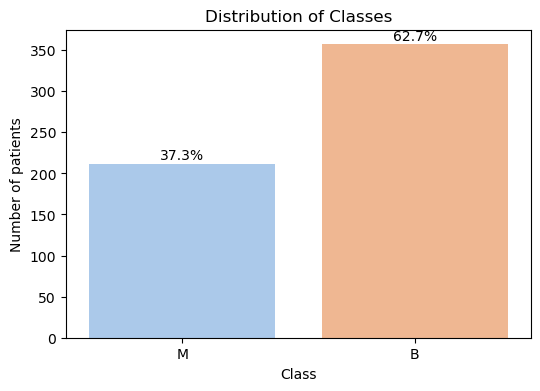

In [49]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y, palette='pastel')

for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + 5,     
        f'{percent:.1f}%',
        ha='center'                     
    )

ax.set_xlabel('Class')
ax.set_ylabel('Number of patients')
ax.set_title('Distribution of Classes')

plt.show()

In [52]:
X.describe().T.style.bar(subset=['mean'], color='#205ff2')\
                            .background_gradient(subset=['std'], cmap='Reds')\
                            .background_gradient(subset=['50%'], cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


Целевые значения разделены в соотношении 63/37. Разный маштаб, особенно area_worst, area_mean с остальными - нужна стандартизация.

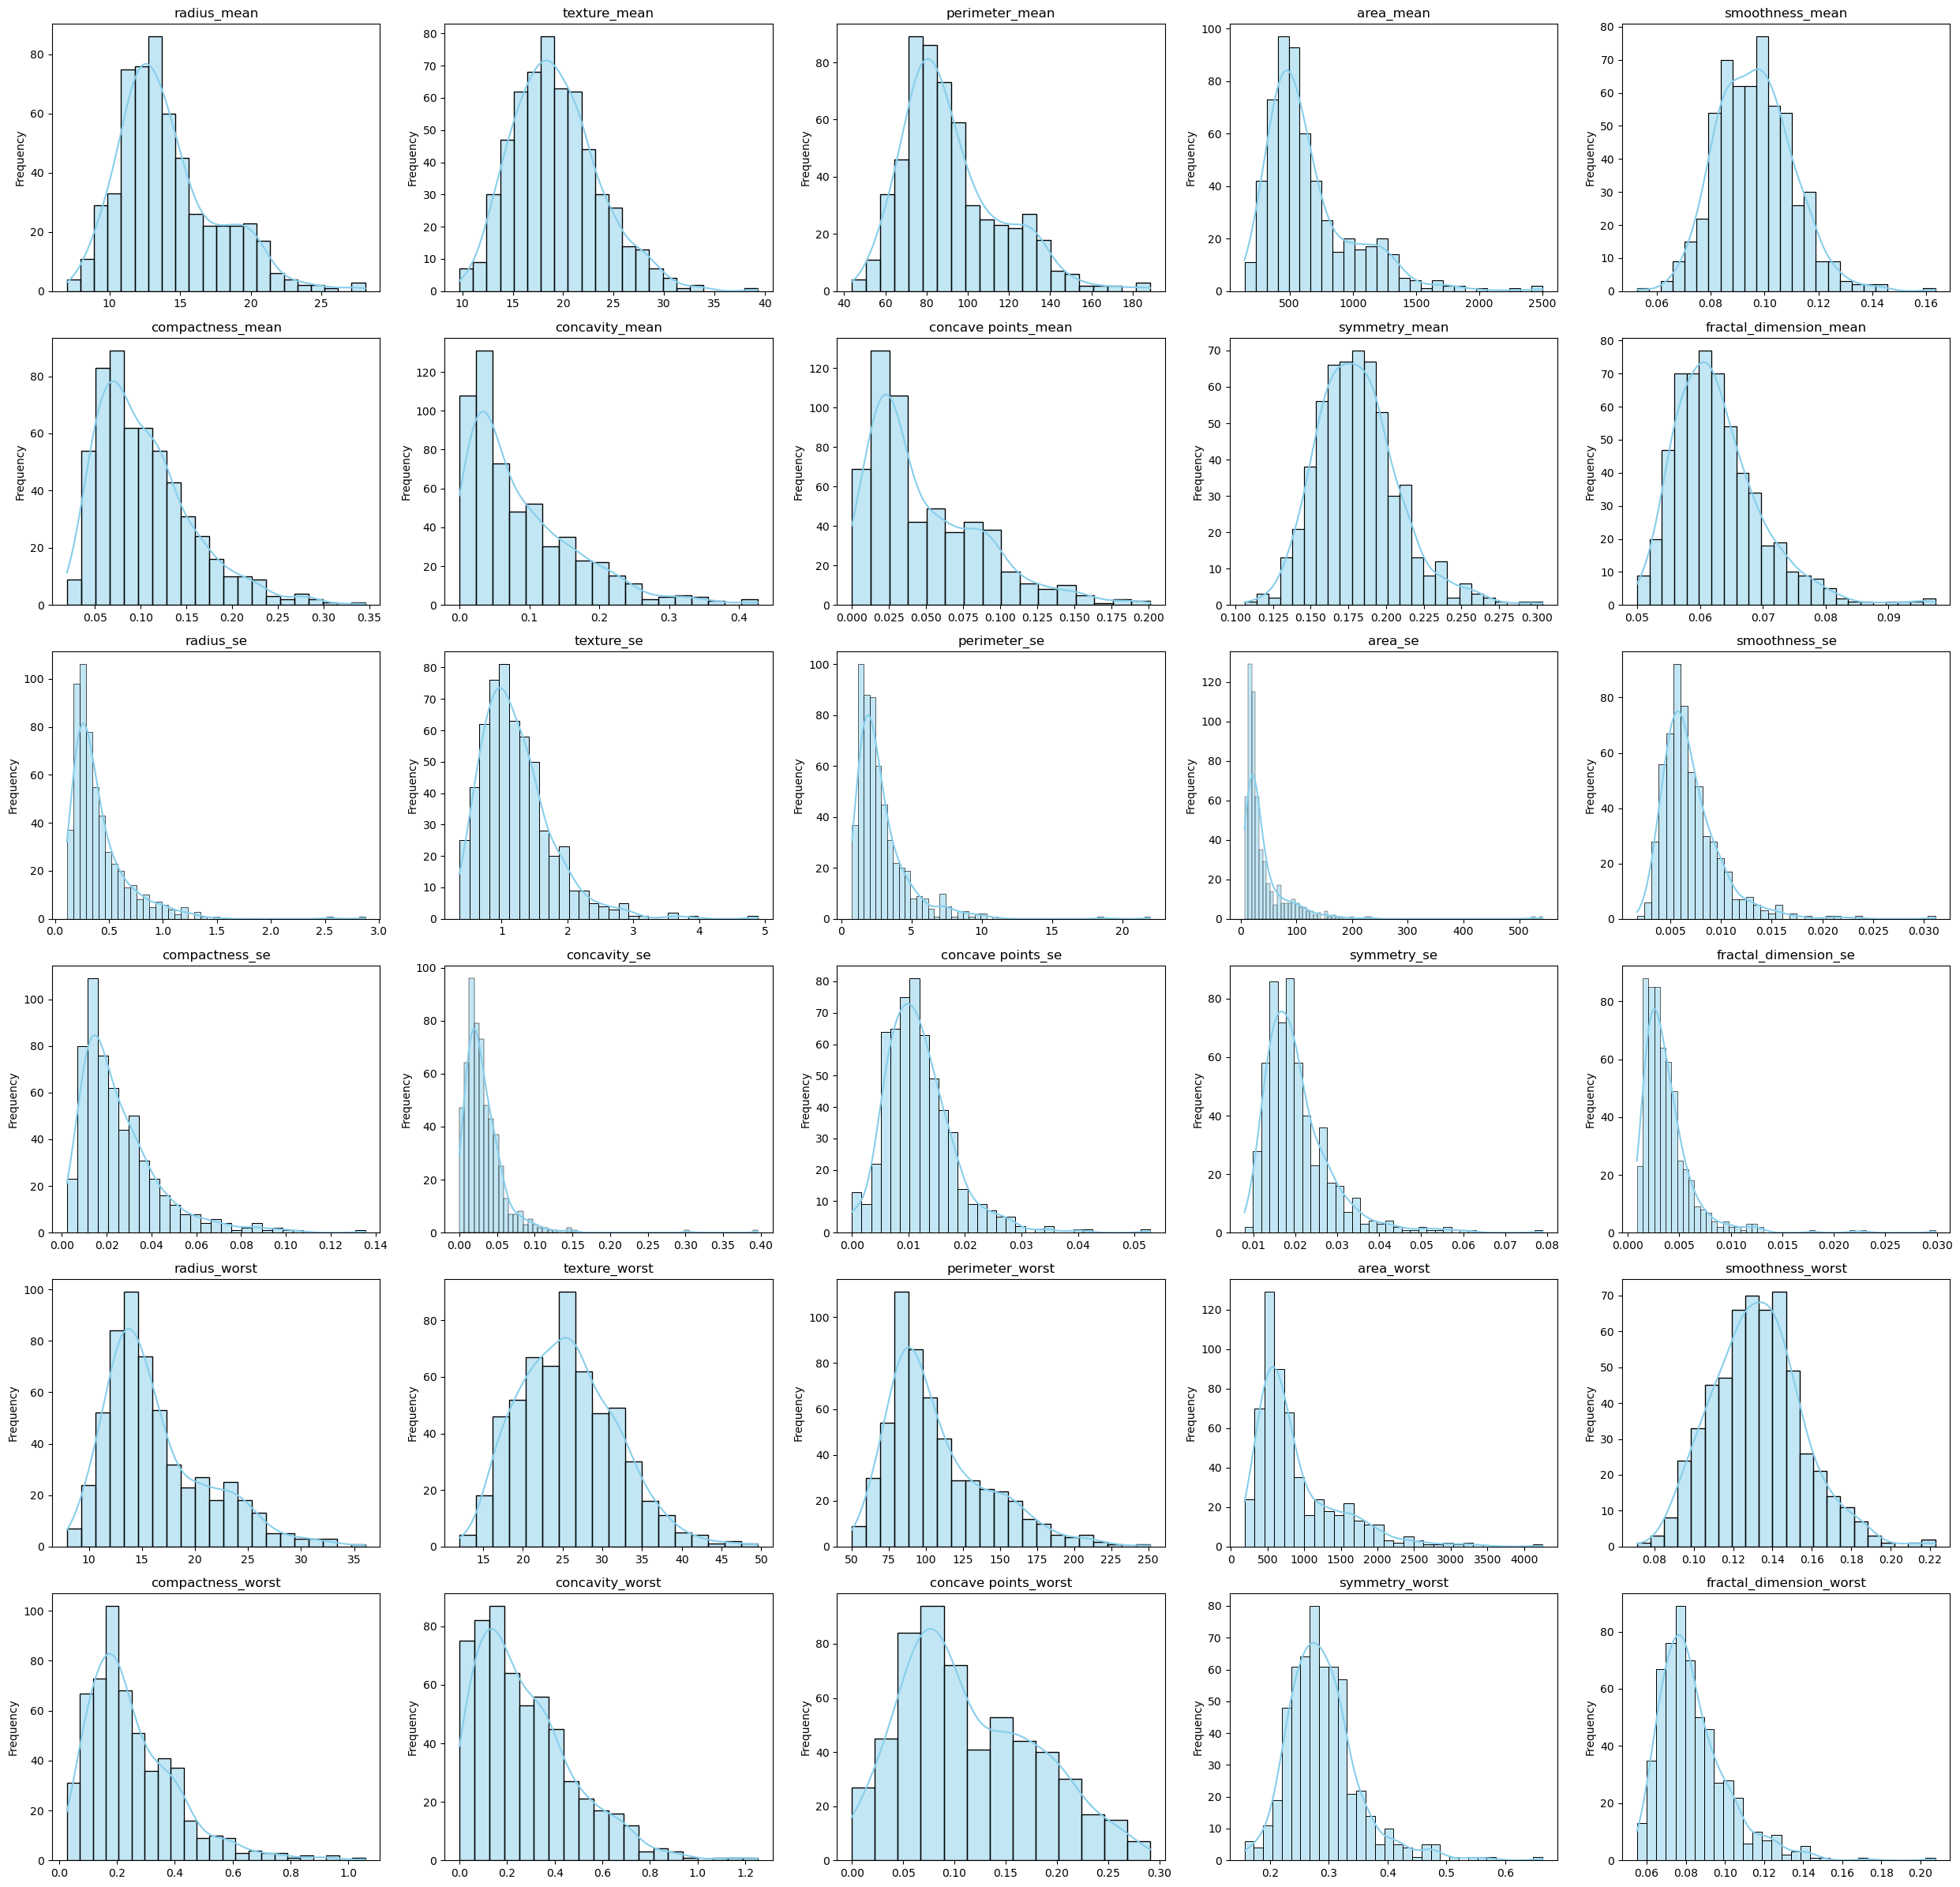

In [57]:
num_cols = X.select_dtypes(include='number').columns

n_cols = 5
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[col].dropna(), kde=True, color='skyblue')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Признак: radius_mean


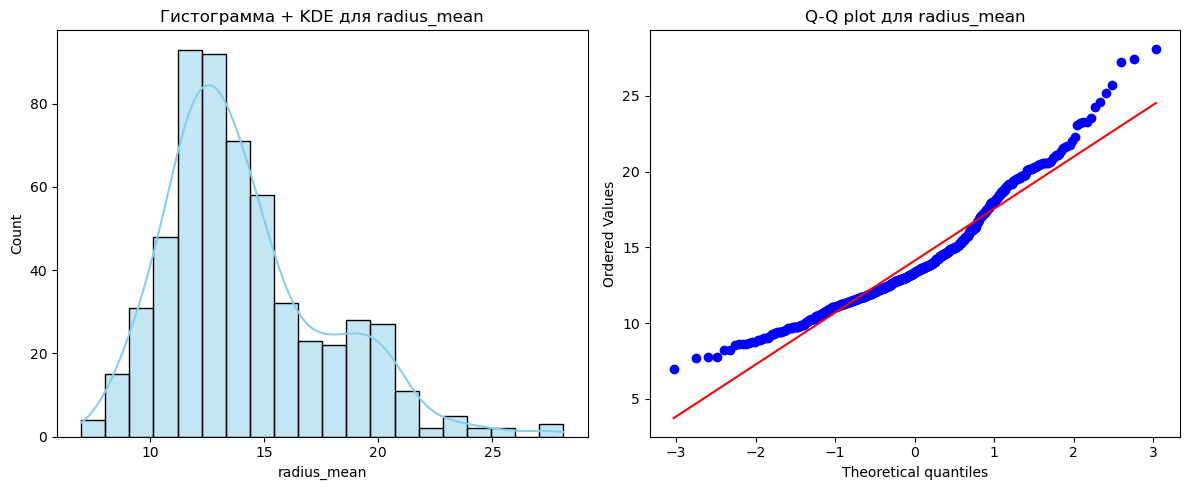

Shapiro-Wilk тест: статистика=0.9411, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: texture_mean


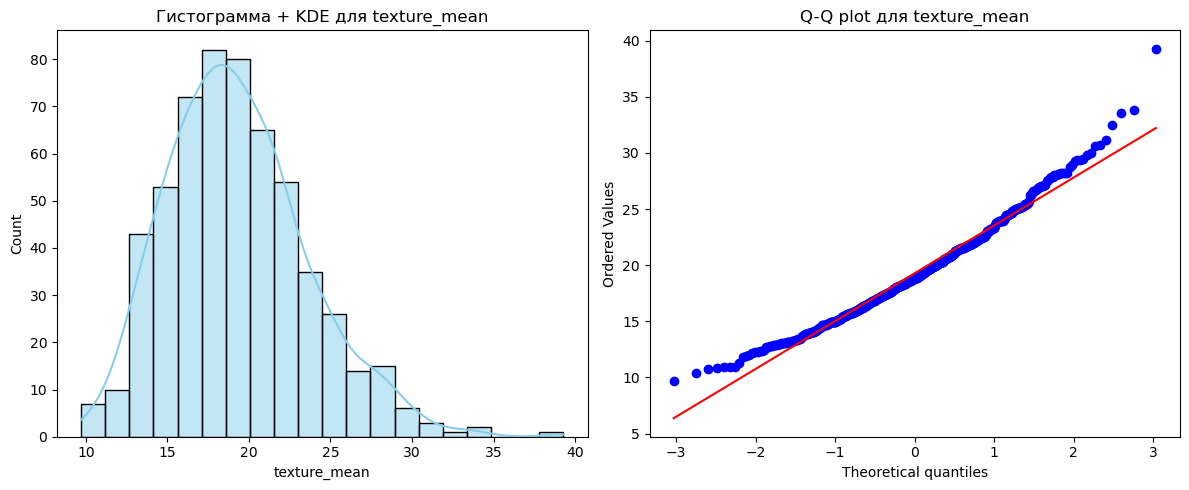

Shapiro-Wilk тест: статистика=0.9767, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: perimeter_mean


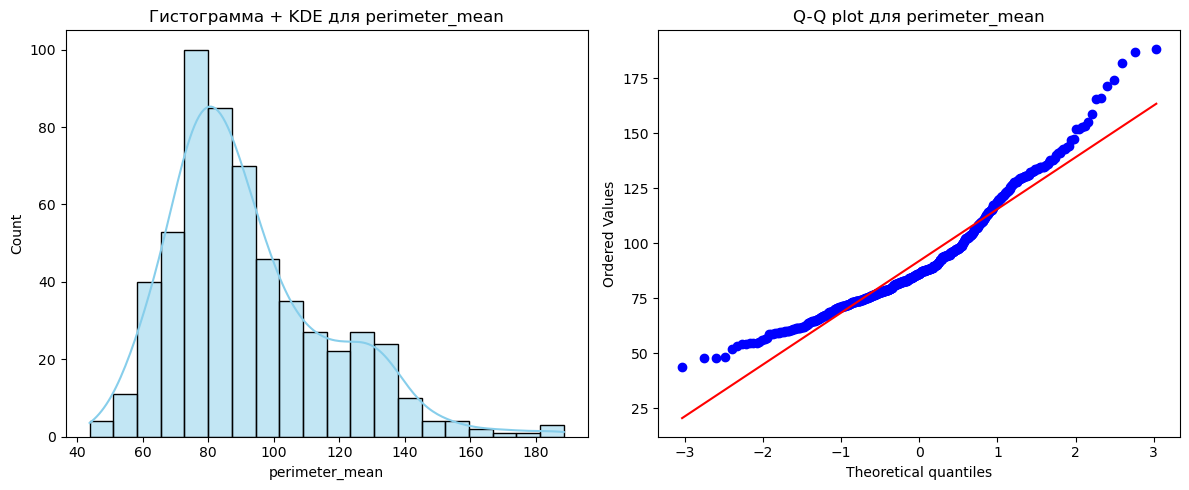

Shapiro-Wilk тест: статистика=0.9362, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: area_mean


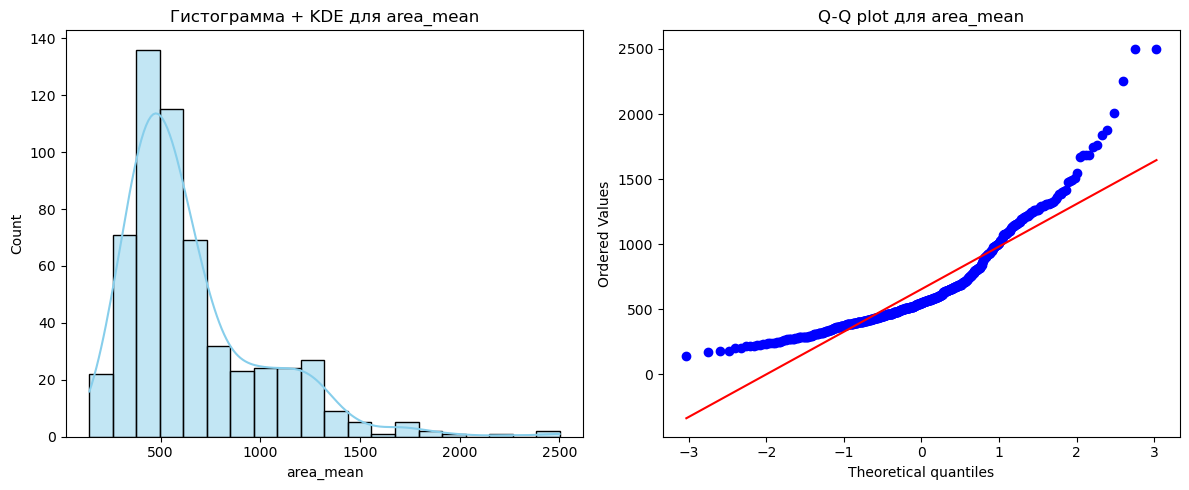

Shapiro-Wilk тест: статистика=0.8584, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: smoothness_mean


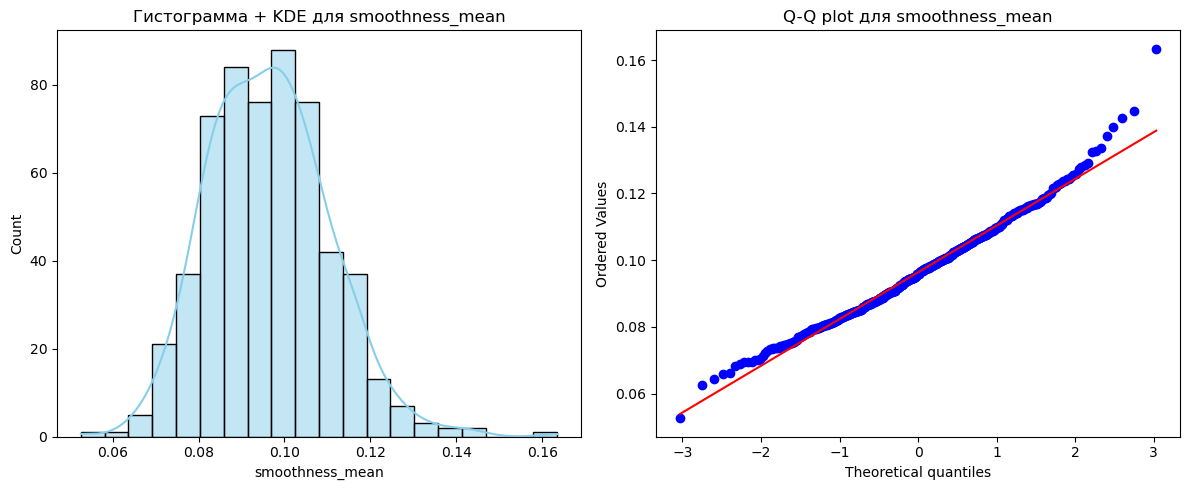

Shapiro-Wilk тест: статистика=0.9875, p-value=0.0001
Данные НЕ нормальные (отклоняем H0)

Признак: compactness_mean


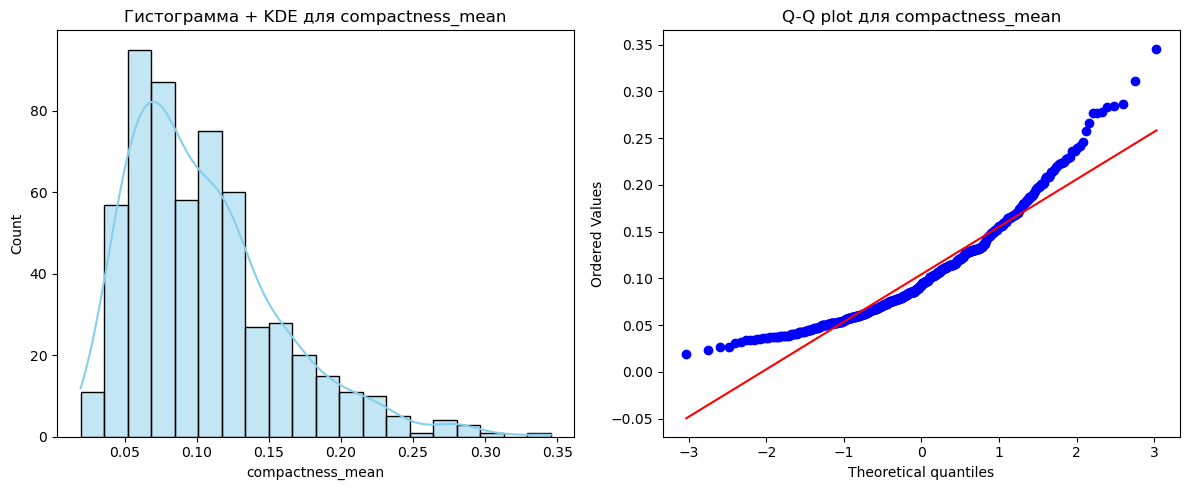

Shapiro-Wilk тест: статистика=0.9170, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concavity_mean


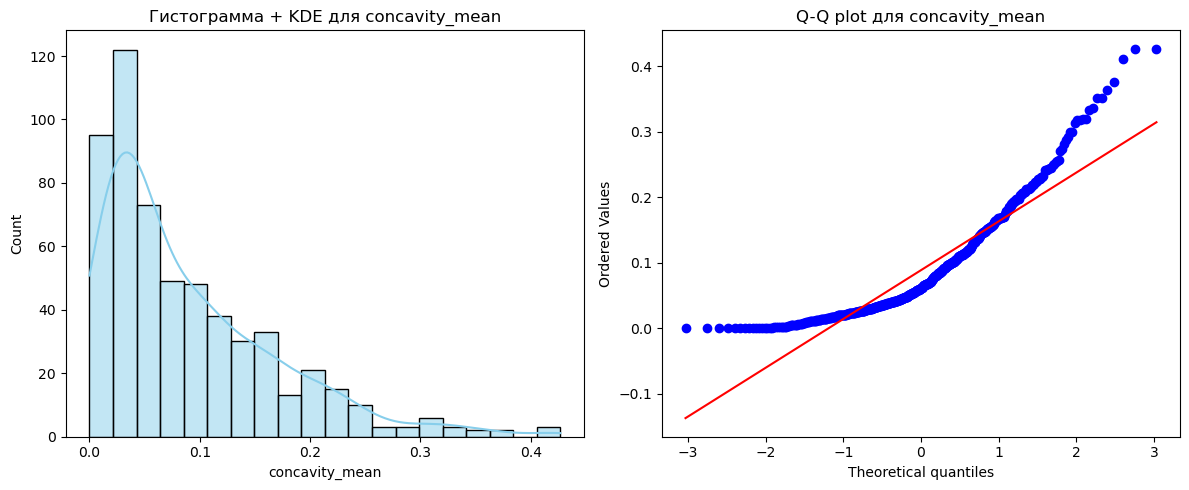

Shapiro-Wilk тест: статистика=0.8668, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concave points_mean


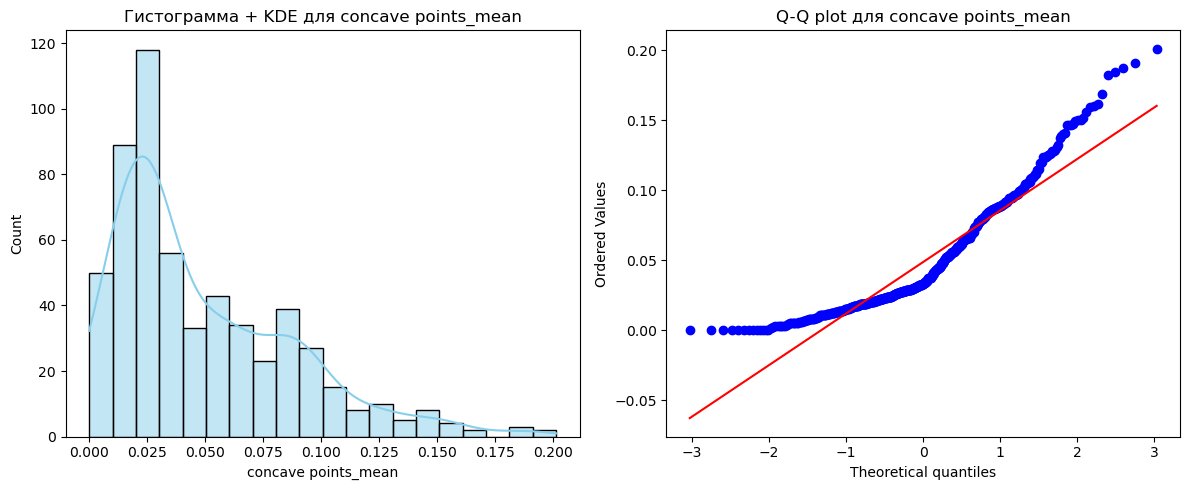

Shapiro-Wilk тест: статистика=0.8917, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: symmetry_mean


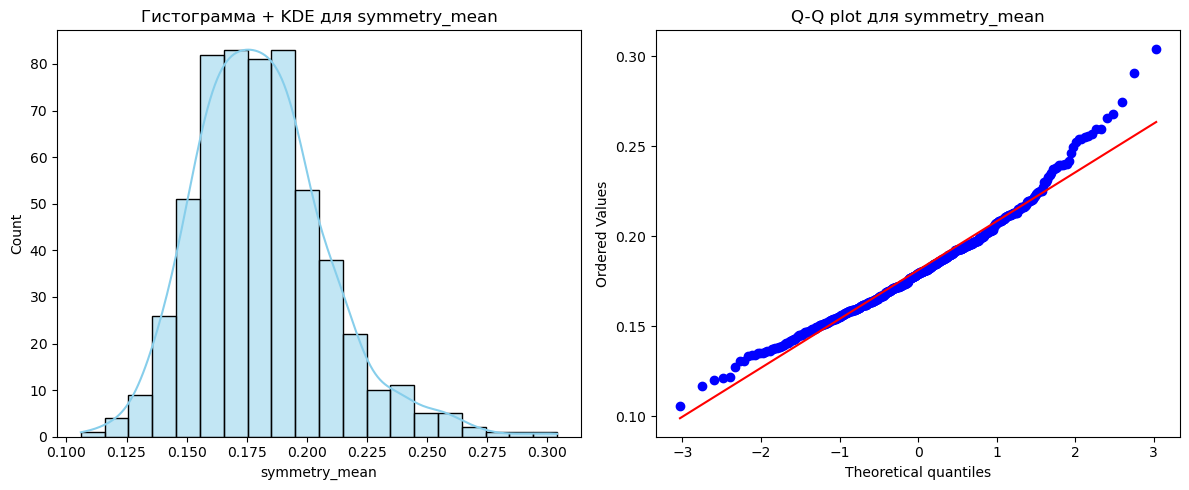

Shapiro-Wilk тест: статистика=0.9726, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: fractal_dimension_mean


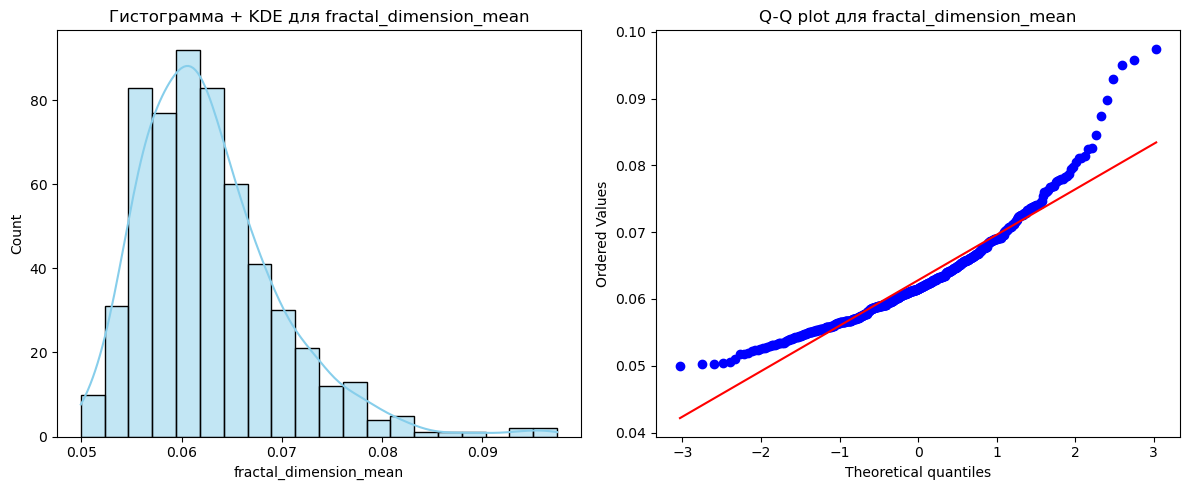

Shapiro-Wilk тест: статистика=0.9233, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: radius_se


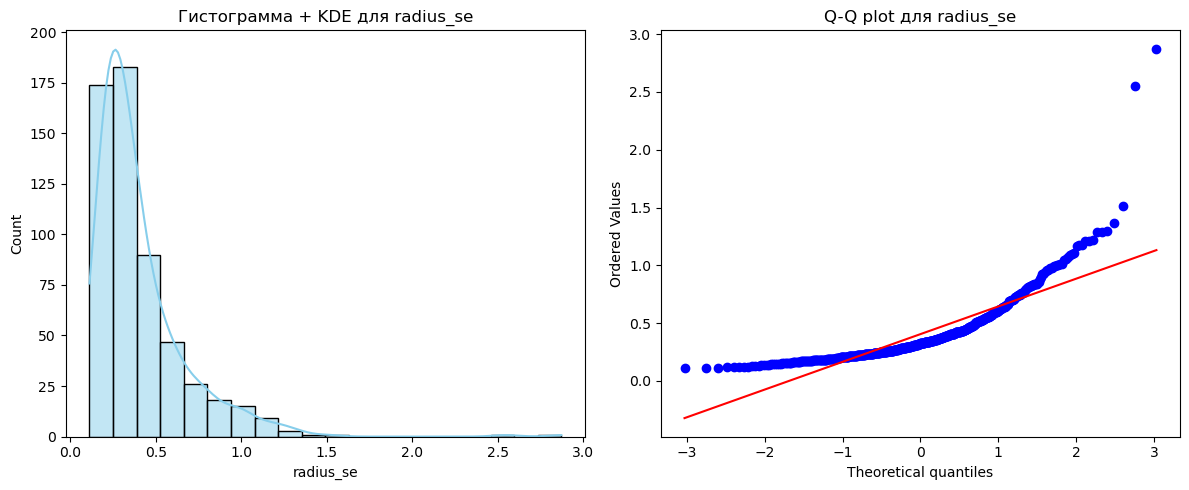

Shapiro-Wilk тест: статистика=0.7456, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: texture_se


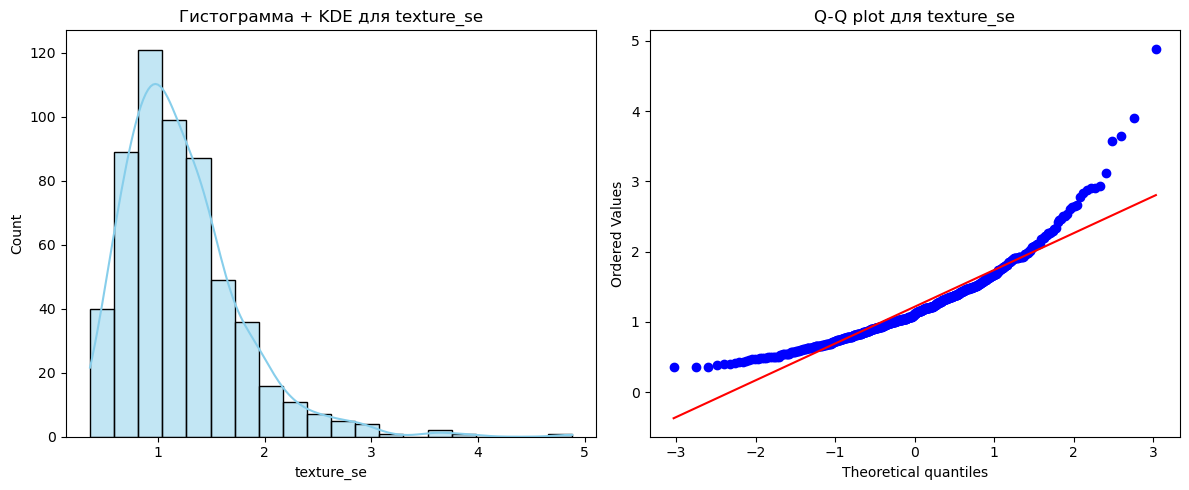

Shapiro-Wilk тест: статистика=0.8962, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: perimeter_se


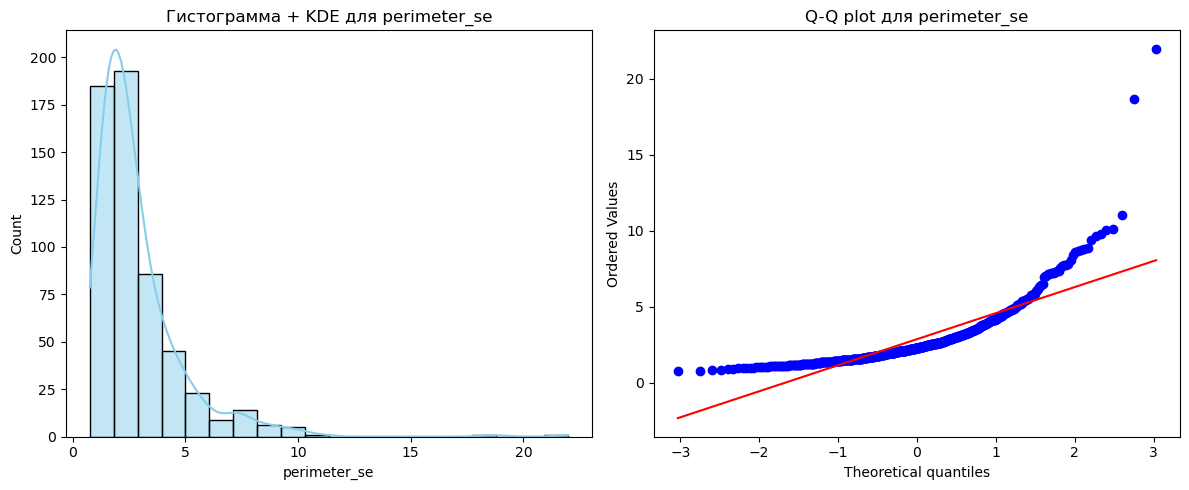

Shapiro-Wilk тест: статистика=0.7182, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: area_se


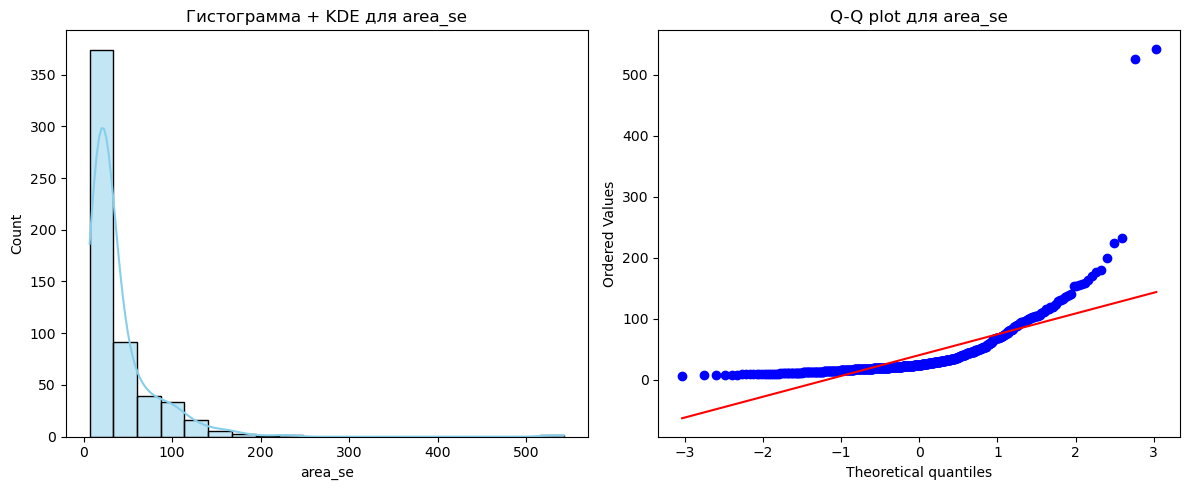

Shapiro-Wilk тест: статистика=0.5638, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: smoothness_se


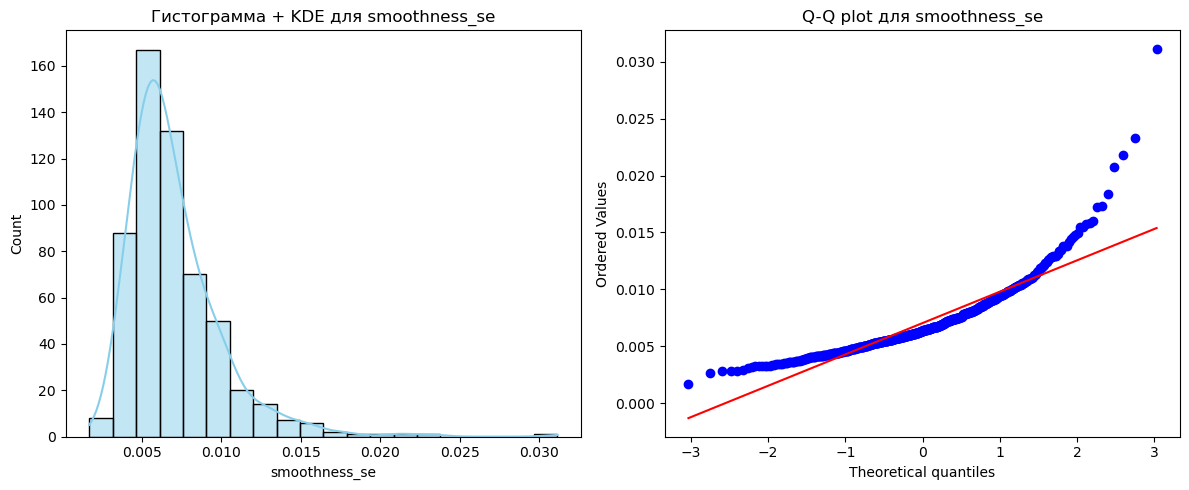

Shapiro-Wilk тест: статистика=0.8384, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: compactness_se


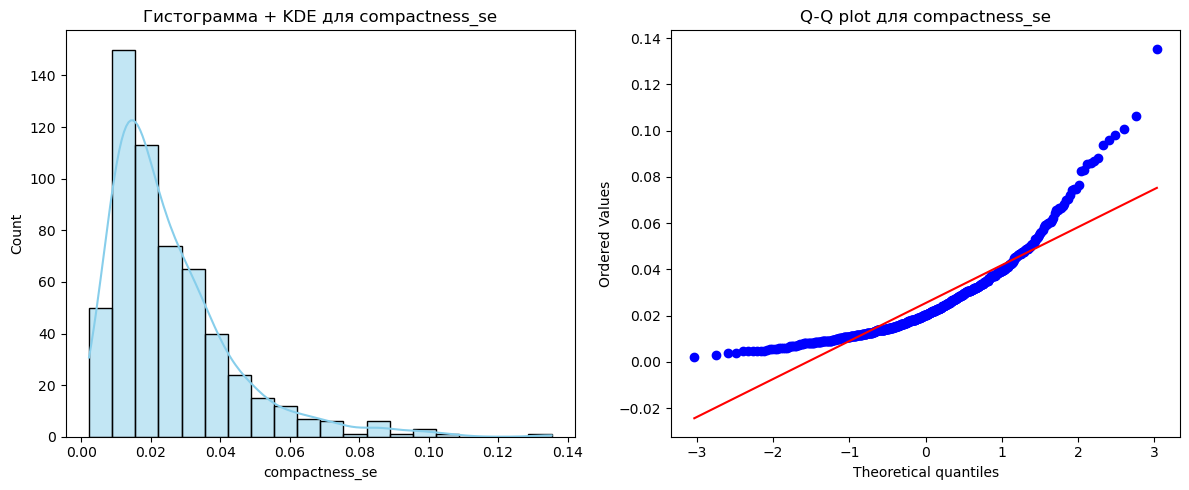

Shapiro-Wilk тест: статистика=0.8369, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concavity_se


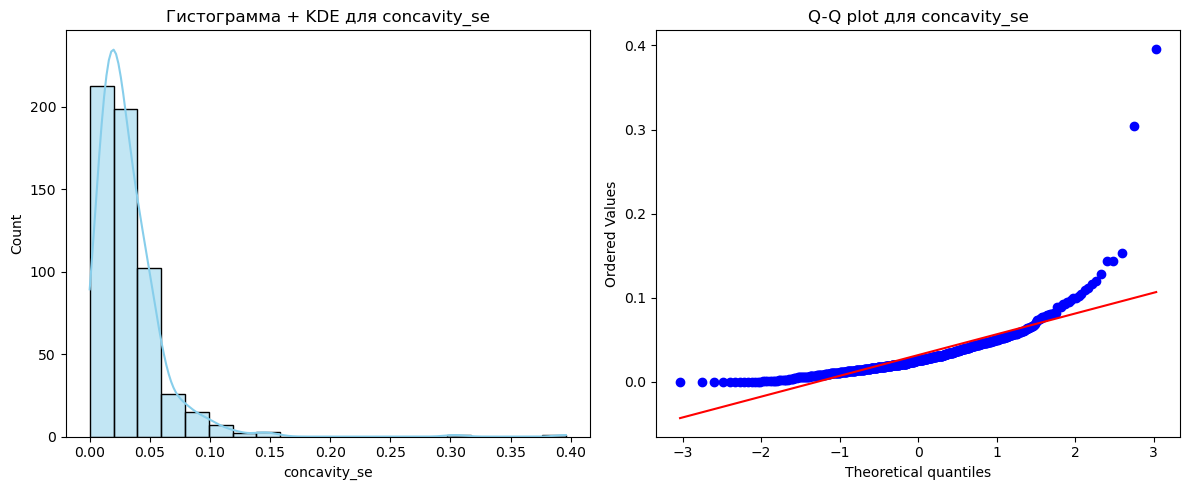

Shapiro-Wilk тест: статистика=0.6721, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concave points_se


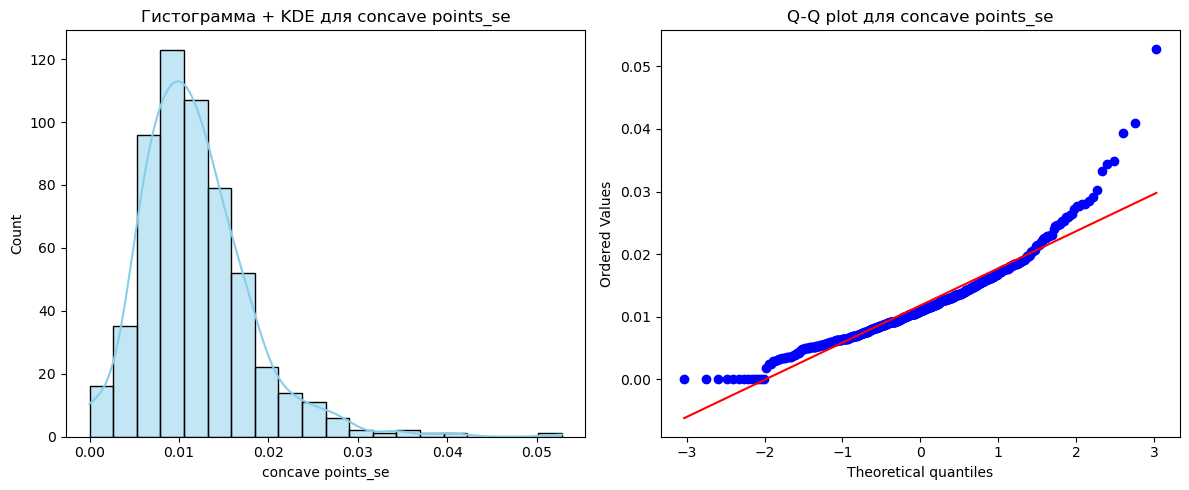

Shapiro-Wilk тест: статистика=0.9197, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: symmetry_se


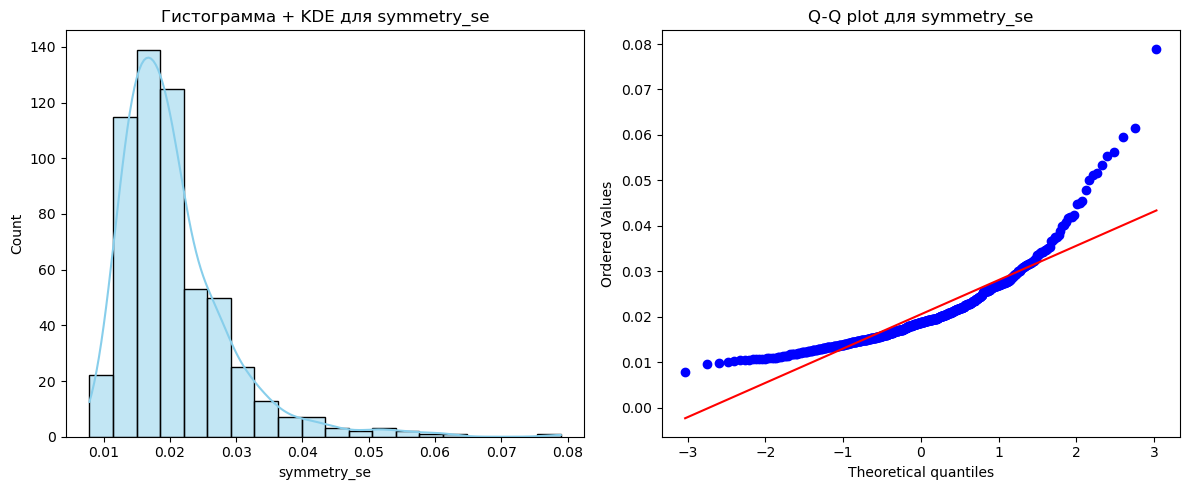

Shapiro-Wilk тест: статистика=0.8284, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: fractal_dimension_se


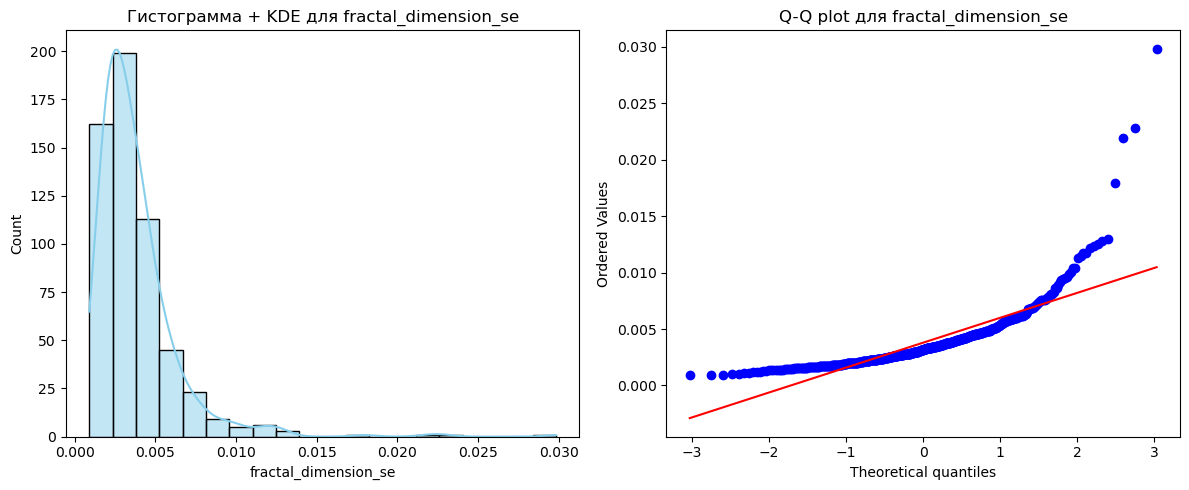

Shapiro-Wilk тест: статистика=0.6951, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: radius_worst


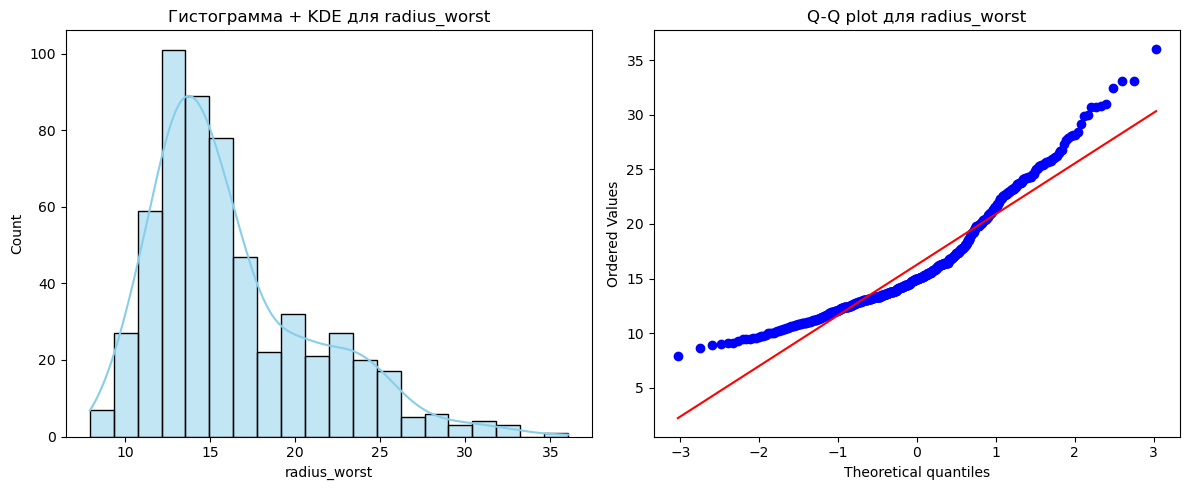

Shapiro-Wilk тест: статистика=0.9135, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: texture_worst


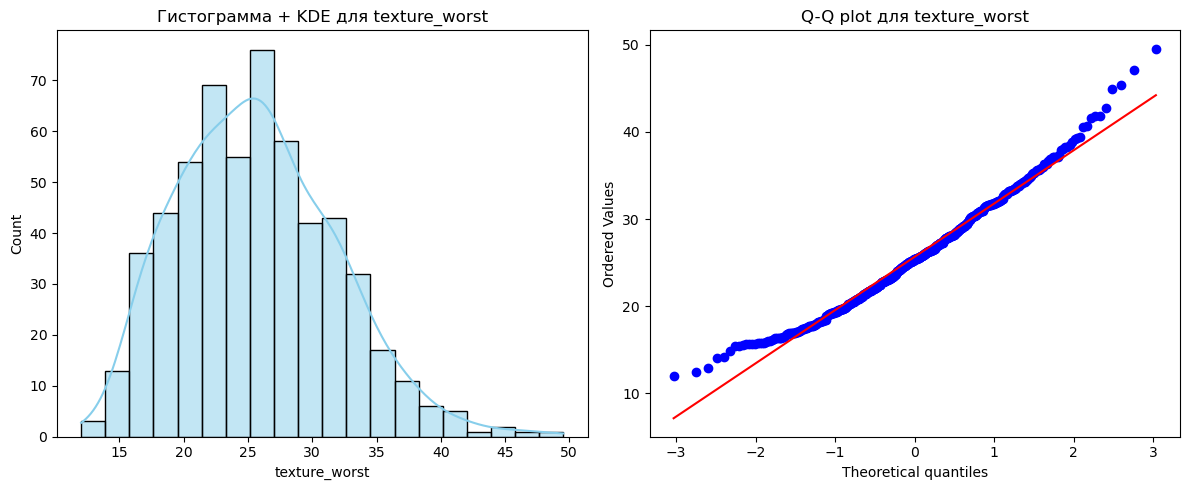

Shapiro-Wilk тест: статистика=0.9826, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: perimeter_worst


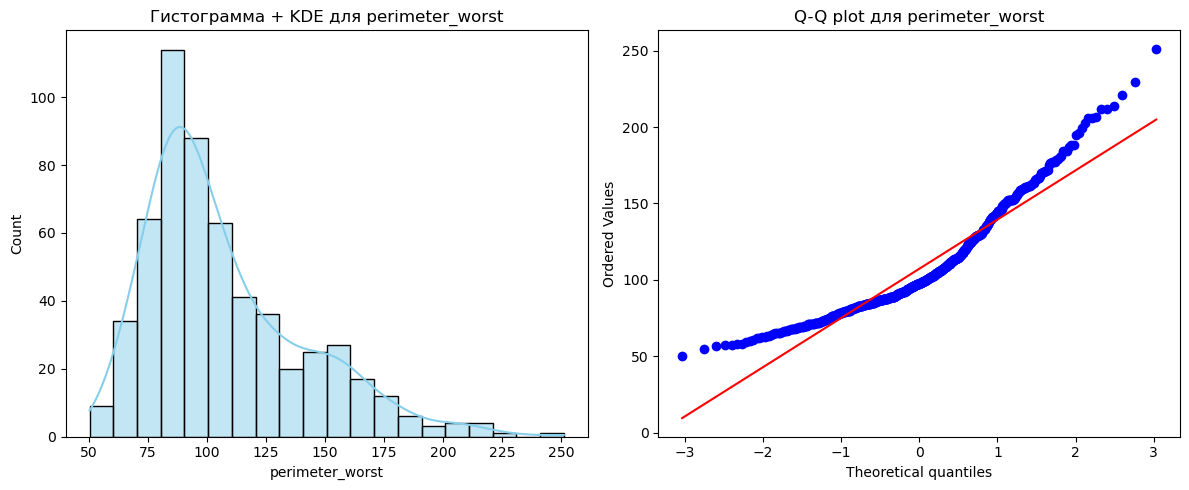

Shapiro-Wilk тест: статистика=0.9126, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: area_worst


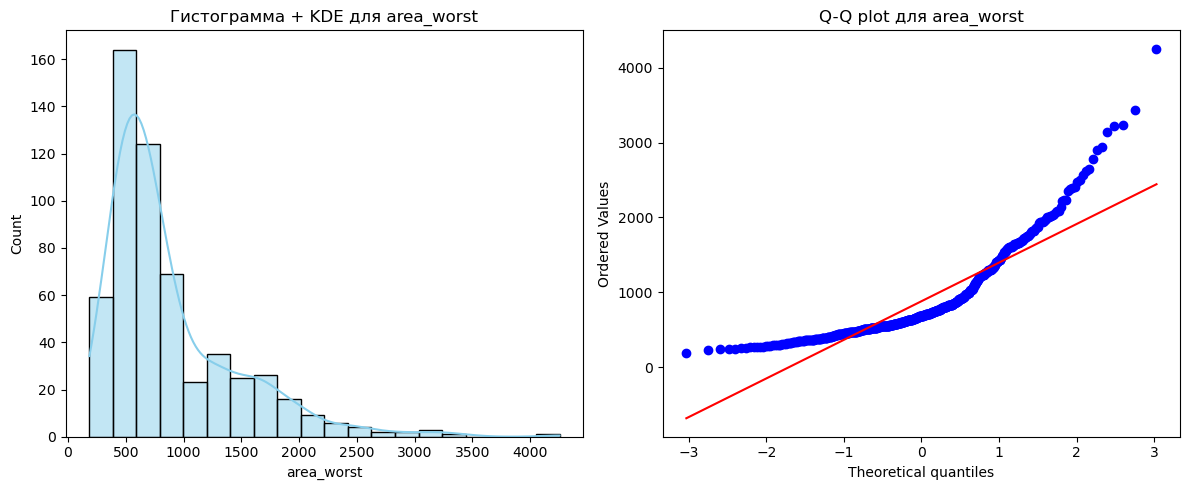

Shapiro-Wilk тест: статистика=0.8161, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: smoothness_worst


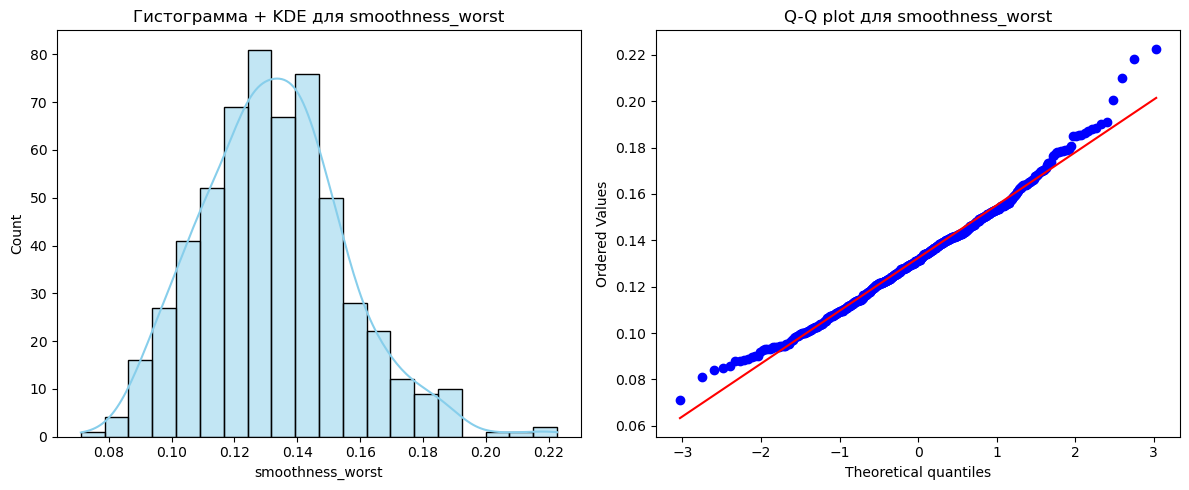

Shapiro-Wilk тест: статистика=0.9886, p-value=0.0002
Данные НЕ нормальные (отклоняем H0)

Признак: compactness_worst


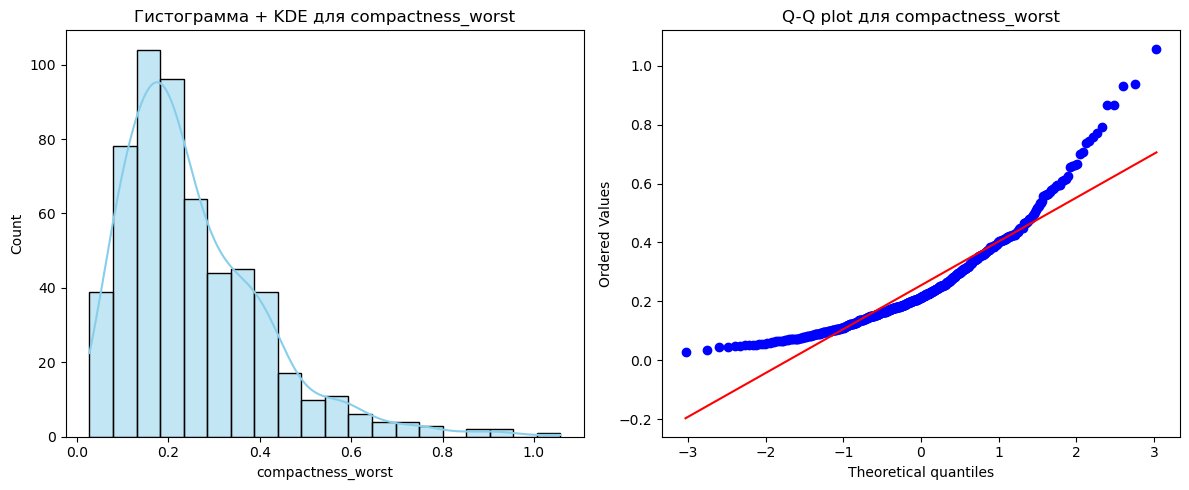

Shapiro-Wilk тест: статистика=0.8911, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concavity_worst


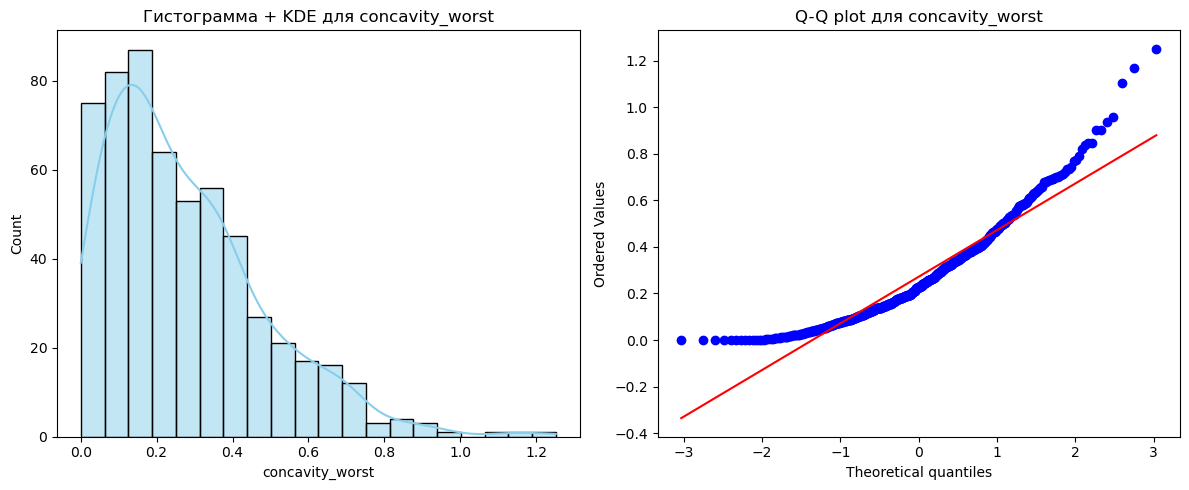

Shapiro-Wilk тест: статистика=0.9175, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: concave points_worst


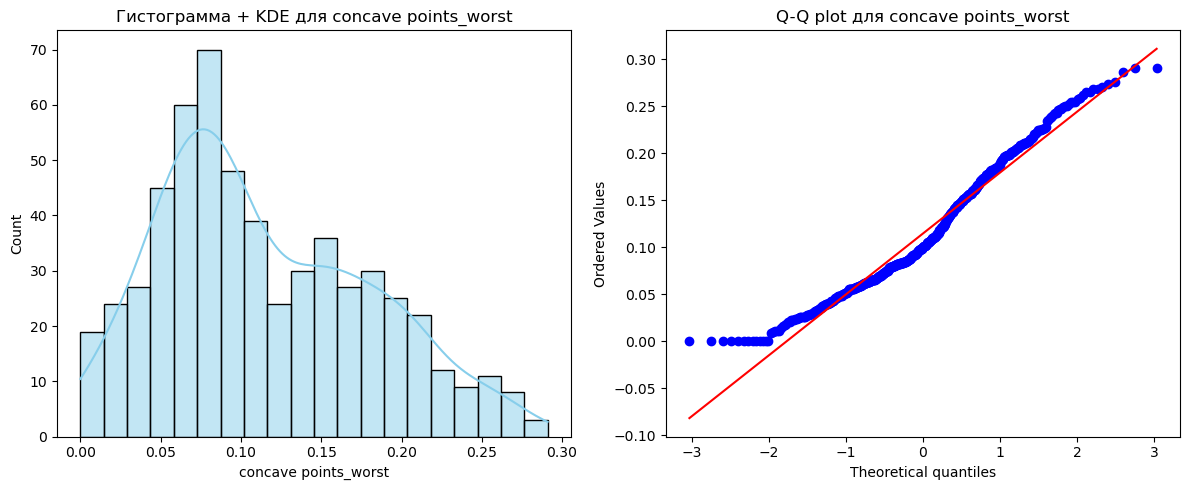

Shapiro-Wilk тест: статистика=0.9648, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: symmetry_worst


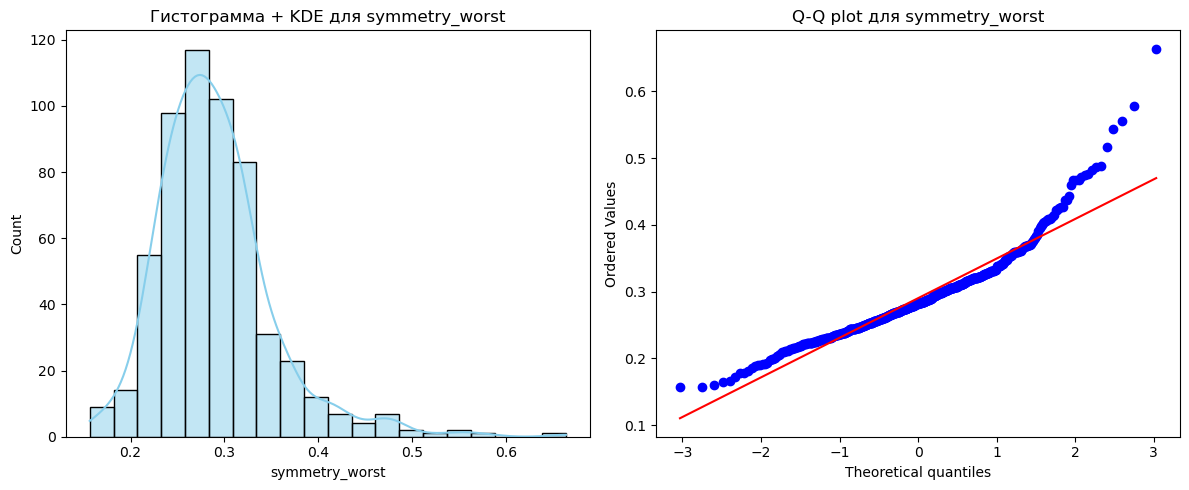

Shapiro-Wilk тест: статистика=0.9161, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)

Признак: fractal_dimension_worst


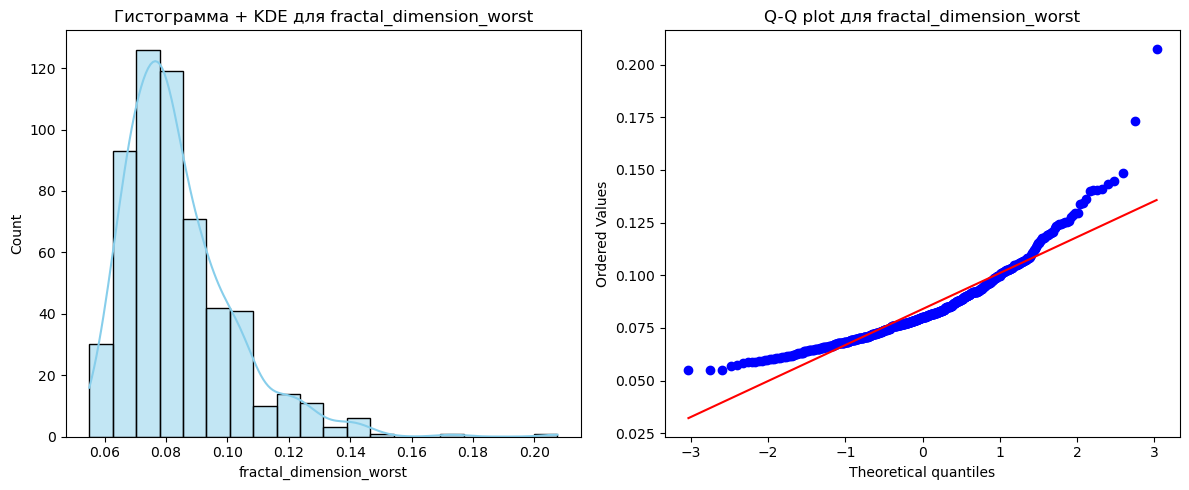

Shapiro-Wilk тест: статистика=0.8895, p-value=0.0000
Данные НЕ нормальные (отклоняем H0)


In [61]:
for column in X.columns:
    print(f"\nПризнак: {column}")
    
    # Гистограмма + кривая плотности
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(X[column], kde=True, bins=20, color='skyblue')
    plt.title(f'Гистограмма + KDE для {column}')
    
    # Q-Q plot
    plt.subplot(1, 2, 2)
    stats.probplot(X[column], dist="norm", plot=plt)
    plt.title(f'Q-Q plot для {column}')
    
    plt.tight_layout()
    plt.show()
    
    # Тест Шапиро–Уилка
    stat, p_value = stats.shapiro(X[column]) 
    print(f"Shapiro-Wilk тест: p-value={p_value:.4f}")
    if p_value > 0.05:
        print("Данные примерно нормальные (не отклоняем H0)")
    else:
        print("Данные НЕ нормальные (отклоняем H0)")

Данные распределены не нормально, имеются сильная скошенность вправо, выбросы. Планируется выбор из логистической регрессии, Decision Tree, Random Forest, SVM (linear), SVM (RBF), XGBoost. Для стандартизации будем использовать RobustScaler

C:\Users\Максим\AppData\Local\Temp\ipykernel_15908\3572953245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


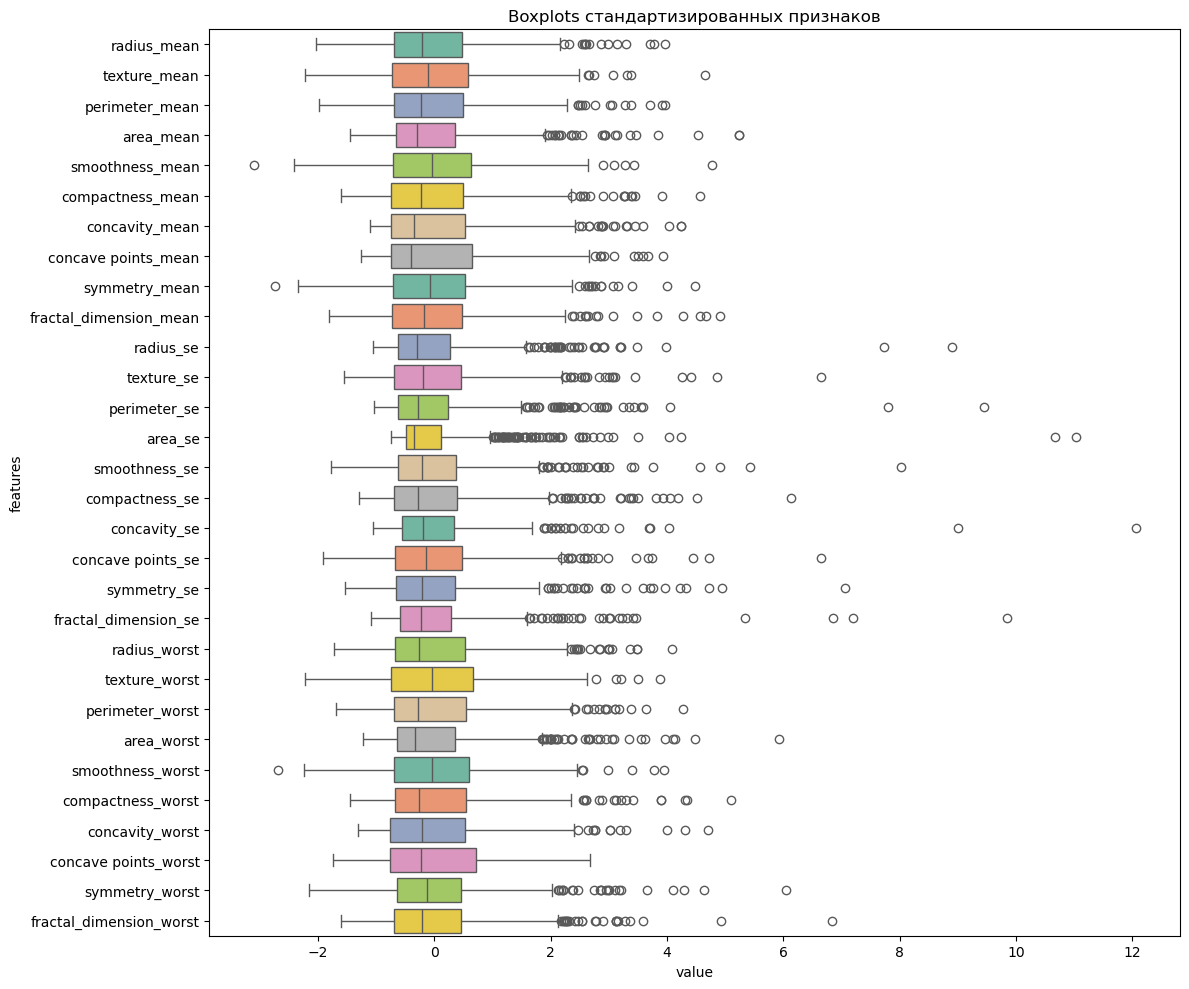

In [64]:
df_stand = (X - X.mean()) / X.std()

data_melt = pd.melt(df_stand, var_name="features", value_name="value")

plt.figure(figsize=(12,10))
sns.boxplot(
    y="features",
    x="value",
    data=data_melt,
    palette="Set2"
)

plt.title("Boxplots стандартизированных признаков")
plt.tight_layout()
plt.show()


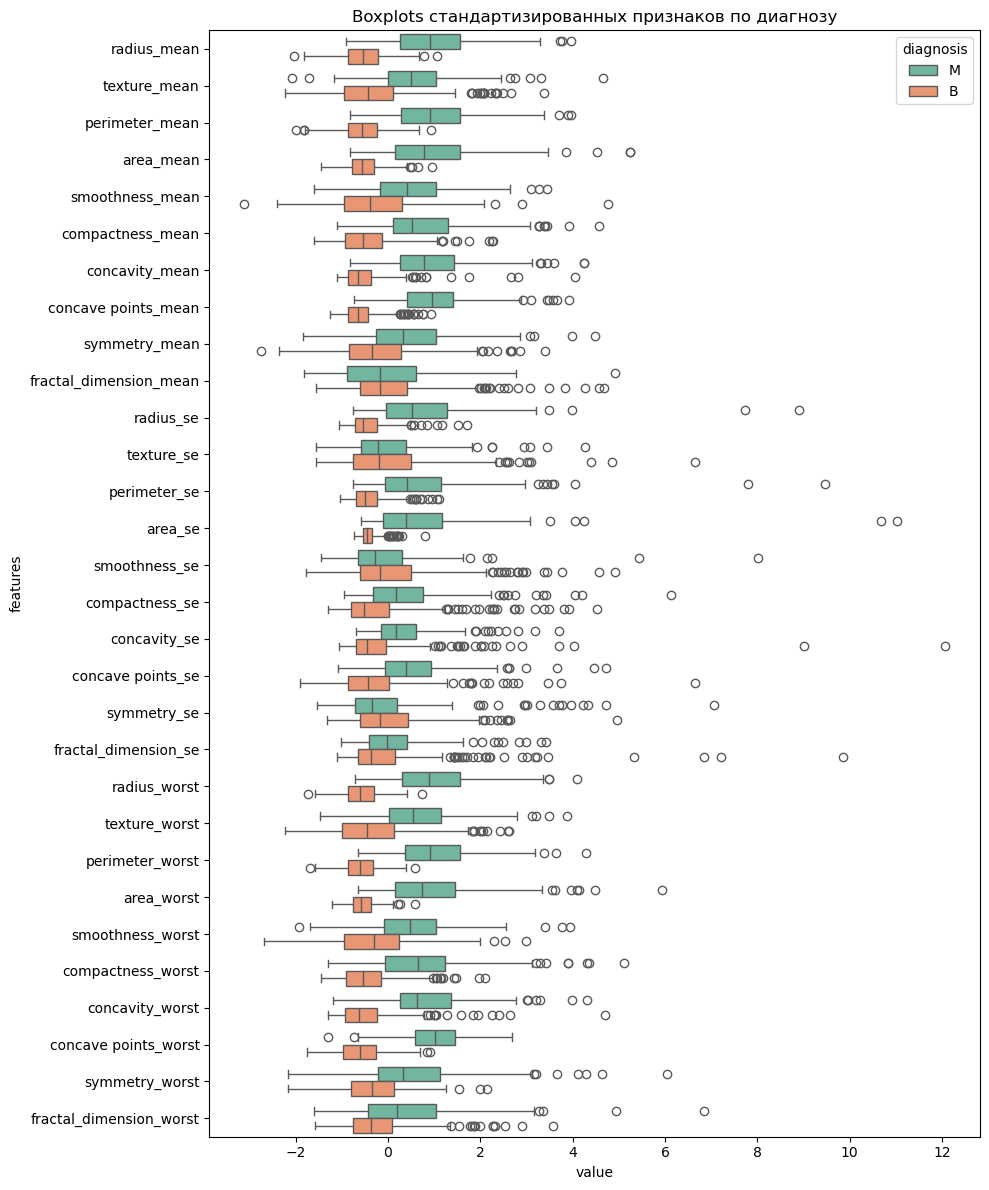

In [66]:
data = pd.concat([y, df_stand], axis=1)
data_melt = pd.melt(data, id_vars="diagnosis", var_name="features", value_name="value")

plt.figure(figsize=(10,12))
sns.boxplot(
    y="features", 
    x="value", 
    hue="diagnosis", 
    data=data_melt, 
    palette="Set2",
    dodge=True
)

plt.title("Boxplots стандартизированных признаков по диагнозу")
plt.tight_layout()
plt.show()

smoothness_mean, symmetry_mean, fractal_dimension_mean, texture_se, smoothness_se, compscthness_se, fractal_dimension_se, smoothness_worst, symmetry_worst, fractal_dimension_worst

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'radius_mean'),
  Text(1, 0, 'texture_mean'),
  Text(2, 0, 'perimeter_mean'),
  Text(3, 0, 'area_mean'),
  Text(4, 0, 'smoothness_mean'),
  Text(5, 0, 'compactness_mean'),
  Text(6, 0, 'concavity_mean'),
  Text(7, 0, 'concave points_mean'),
  Text(8, 0, 'symmetry_mean'),
  Text(9, 0, 'fractal_dimension_mean'),
  Text(10, 0, 'radius_se'),
  Text(11, 0, 'texture_se'),
  Text(12, 0, 'perimeter_se'),
  Text(13, 0, 'area_se'),
  Text(14, 0, 'smoothness_se')])

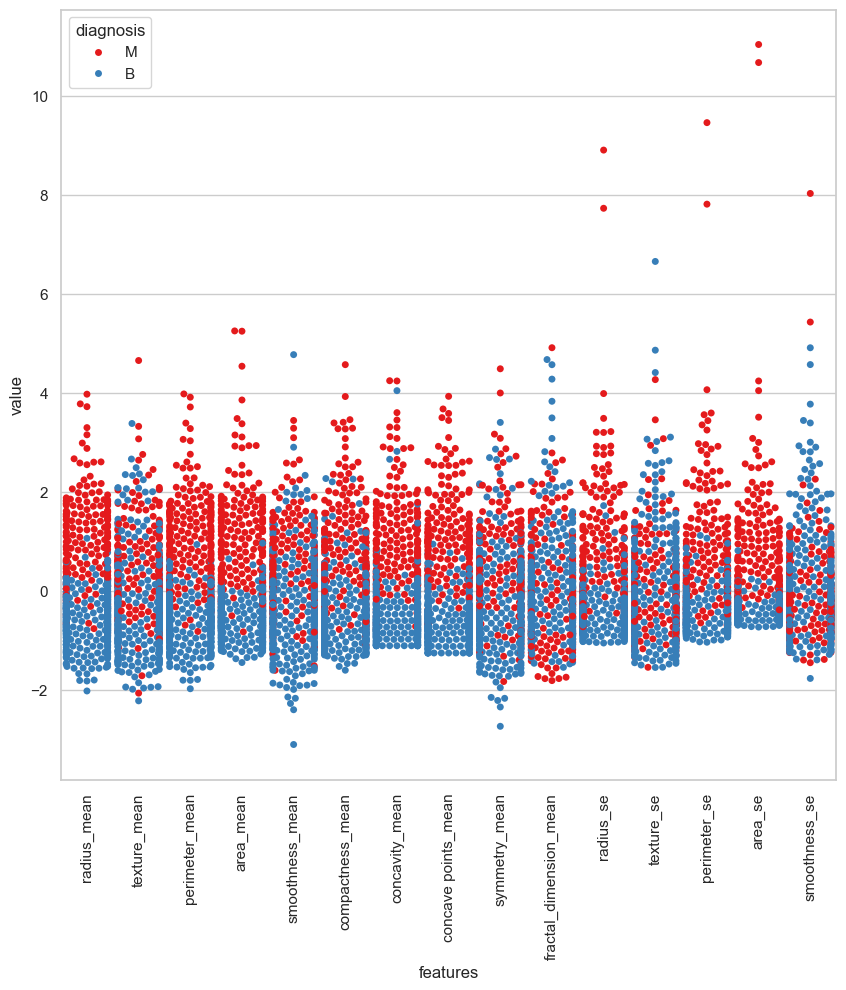

In [69]:
data = pd.concat([y,df_stand.iloc[:,0:15]],axis=1)
data = pd.melt(data,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')

sns.set(style="whitegrid", palette="Set1")
plt.figure(figsize=(10,10))

sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)
plt.xticks(rotation=90)

texture_mean, smoothness_mean, compoctness_mean, symmetry_mean, fractal_dimension_mean, texture_se, smoothness_se

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'compactness_se'),
  Text(1, 0, 'concavity_se'),
  Text(2, 0, 'concave points_se'),
  Text(3, 0, 'symmetry_se'),
  Text(4, 0, 'fractal_dimension_se'),
  Text(5, 0, 'radius_worst'),
  Text(6, 0, 'texture_worst'),
  Text(7, 0, 'perimeter_worst'),
  Text(8, 0, 'area_worst'),
  Text(9, 0, 'smoothness_worst'),
  Text(10, 0, 'compactness_worst'),
  Text(11, 0, 'concavity_worst'),
  Text(12, 0, 'concave points_worst'),
  Text(13, 0, 'symmetry_worst'),
  Text(14, 0, 'fractal_dimension_worst')])

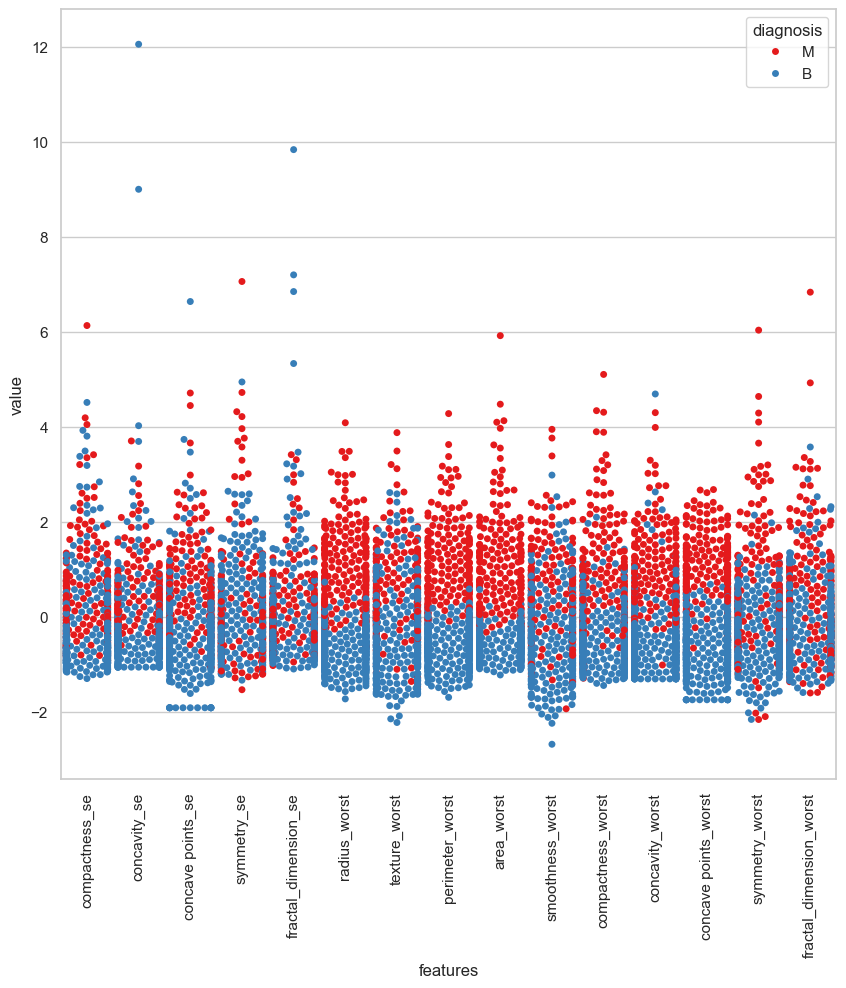

In [73]:
data = pd.concat([y,df_stand.iloc[:,15:30]],axis=1)
data = pd.melt(data,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)
plt.xticks(rotation=90)

compactness_se, concavity_se, symmetry_se, fractal_dimencion_se, texture_worst, smoothness_worst, symmetry_worst, fractal_dimencion_worst

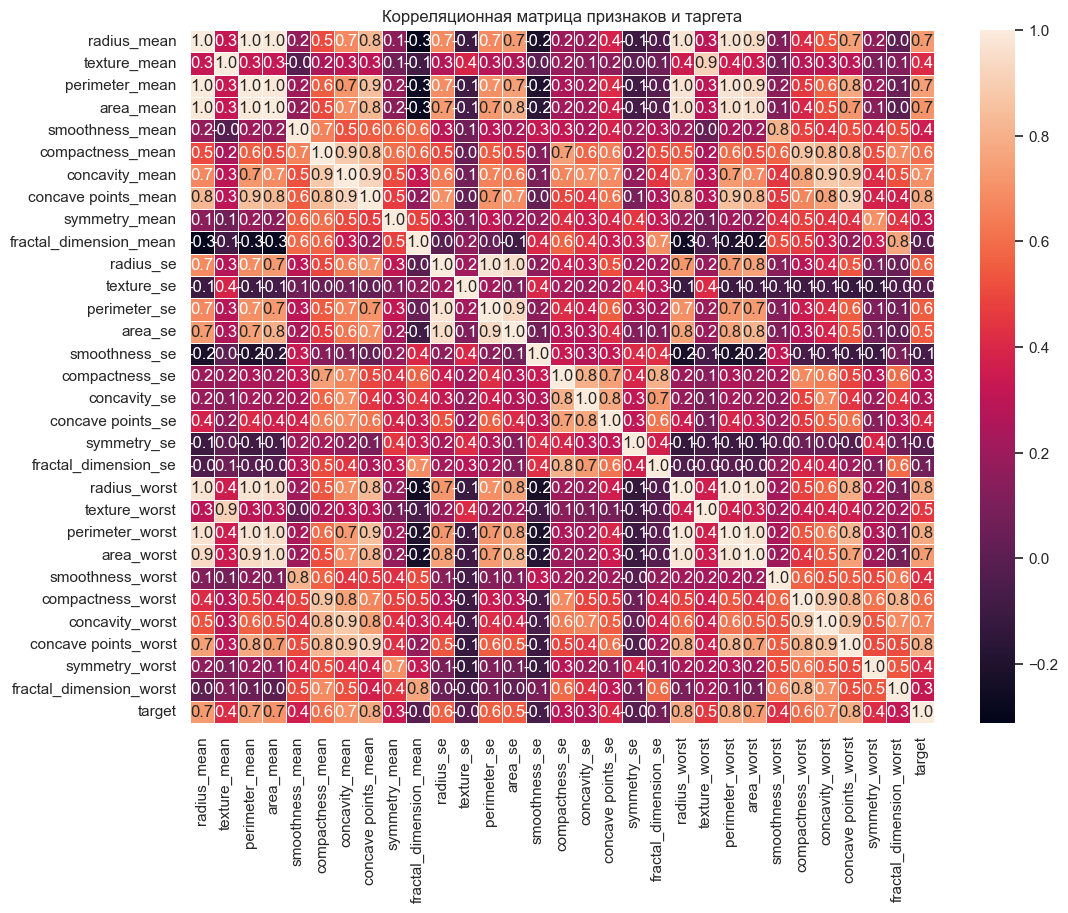

In [91]:
data_for_hm = X.copy()
data_for_hm['target'] = y.map({'B':0, 'M':1})

corrmat = data_for_hm.corr()

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, linewidths=.5, fmt='.1f', ax=ax)
plt.title("Корреляционная матрица признаков и таргета")
plt.show()


Предварительный анализ показал, что все признаки распределены ненормально, имеют выбросы и разный масштаб значений.
На boxplot и роевых графиках видно, что часть признаков (например, concavity_worst, area_mean, smoothness_worst) хорошо разделяет классы, тогда как другие — слабее.
Тепловая карта выявила группы сильно коррелирующих признаков, что указывает на необходимость отбора, чтобы избежать избыточности.
В целом, уже на этом этапе можно выделить признаки, которые перспективны для дальнейшего анализа и построения модели.

In [181]:
cols_keep = [
    'texture_mean', 'area_mean', 'smoothness_mean', 'concave points_mean',
    'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se', 
    'smoothness_se', 'symmetry_se', 'symmetry_worst', 'compactness_se', 'concave points_se',
    'smoothness_worst', 'concavity_worst',
]
X_filtered = X[cols_keep]

<Axes: >

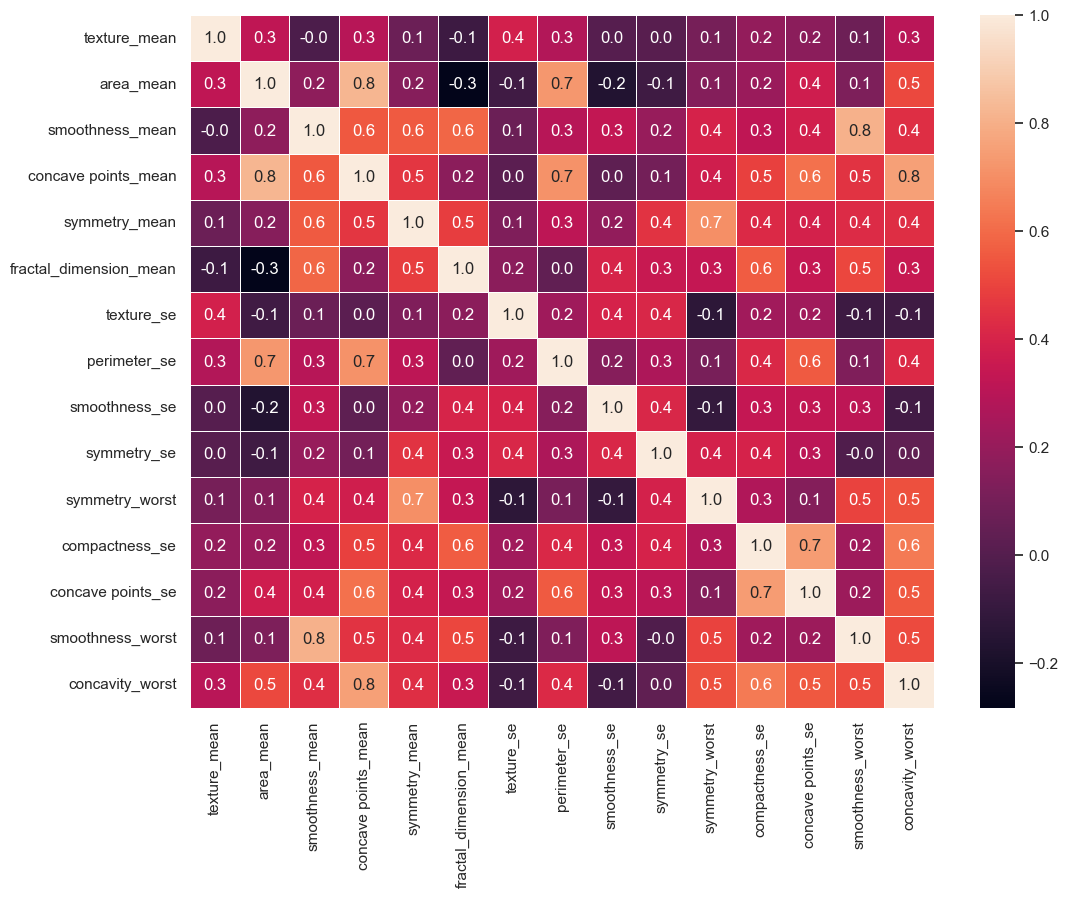

In [183]:
corrmat = X_filtered.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, linewidths=.5, fmt= '.1f',ax=ax)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'texture_mean'),
  Text(1, 0, 'area_mean'),
  Text(2, 0, 'smoothness_mean'),
  Text(3, 0, 'concave points_mean'),
  Text(4, 0, 'symmetry_mean'),
  Text(5, 0, 'fractal_dimension_mean'),
  Text(6, 0, 'texture_se'),
  Text(7, 0, 'perimeter_se'),
  Text(8, 0, 'smoothness_se'),
  Text(9, 0, 'symmetry_se'),
  Text(10, 0, 'symmetry_worst'),
  Text(11, 0, 'compactness_se'),
  Text(12, 0, 'concave points_se'),
  Text(13, 0, 'smoothness_worst'),
  Text(14, 0, 'concavity_worst')])

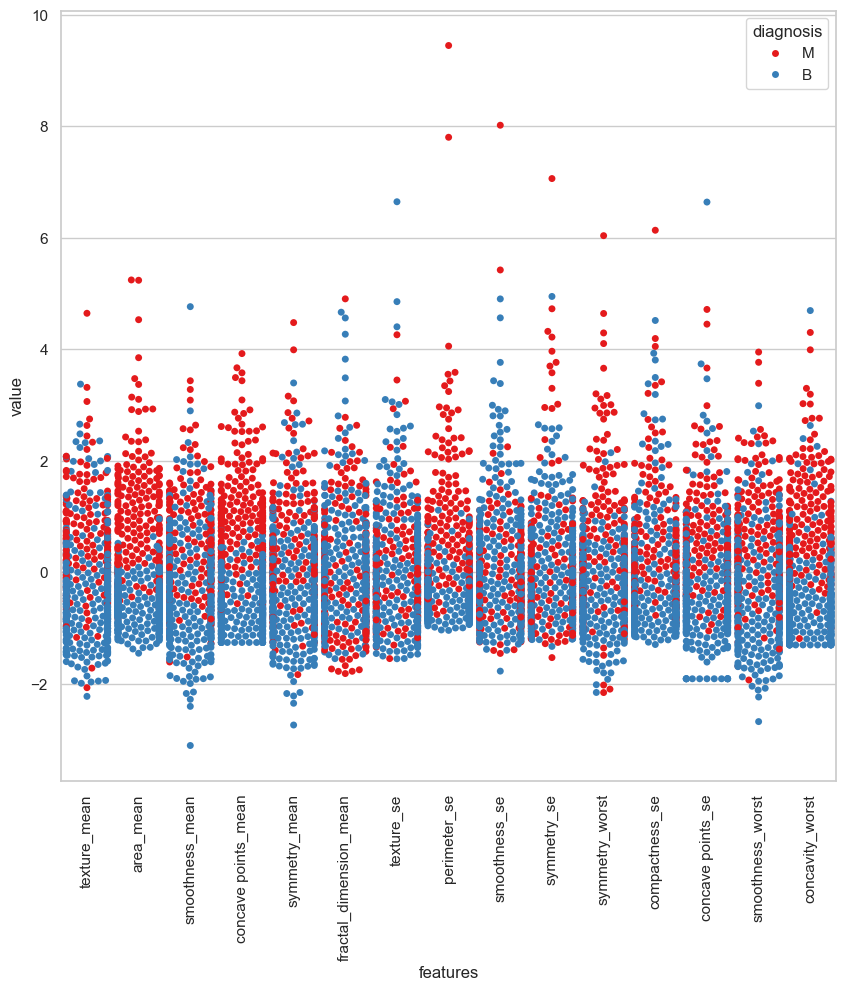

In [185]:
sns.set(style="whitegrid", palette="Set1")

data = X_filtered.copy()
data = (data - data.mean()) / (data.std())             
data = pd.concat([y,data],axis=1)
data = pd.melt(data,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))

sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)
plt.xticks(rotation=90)

<Figure size 1200x1200 with 0 Axes>

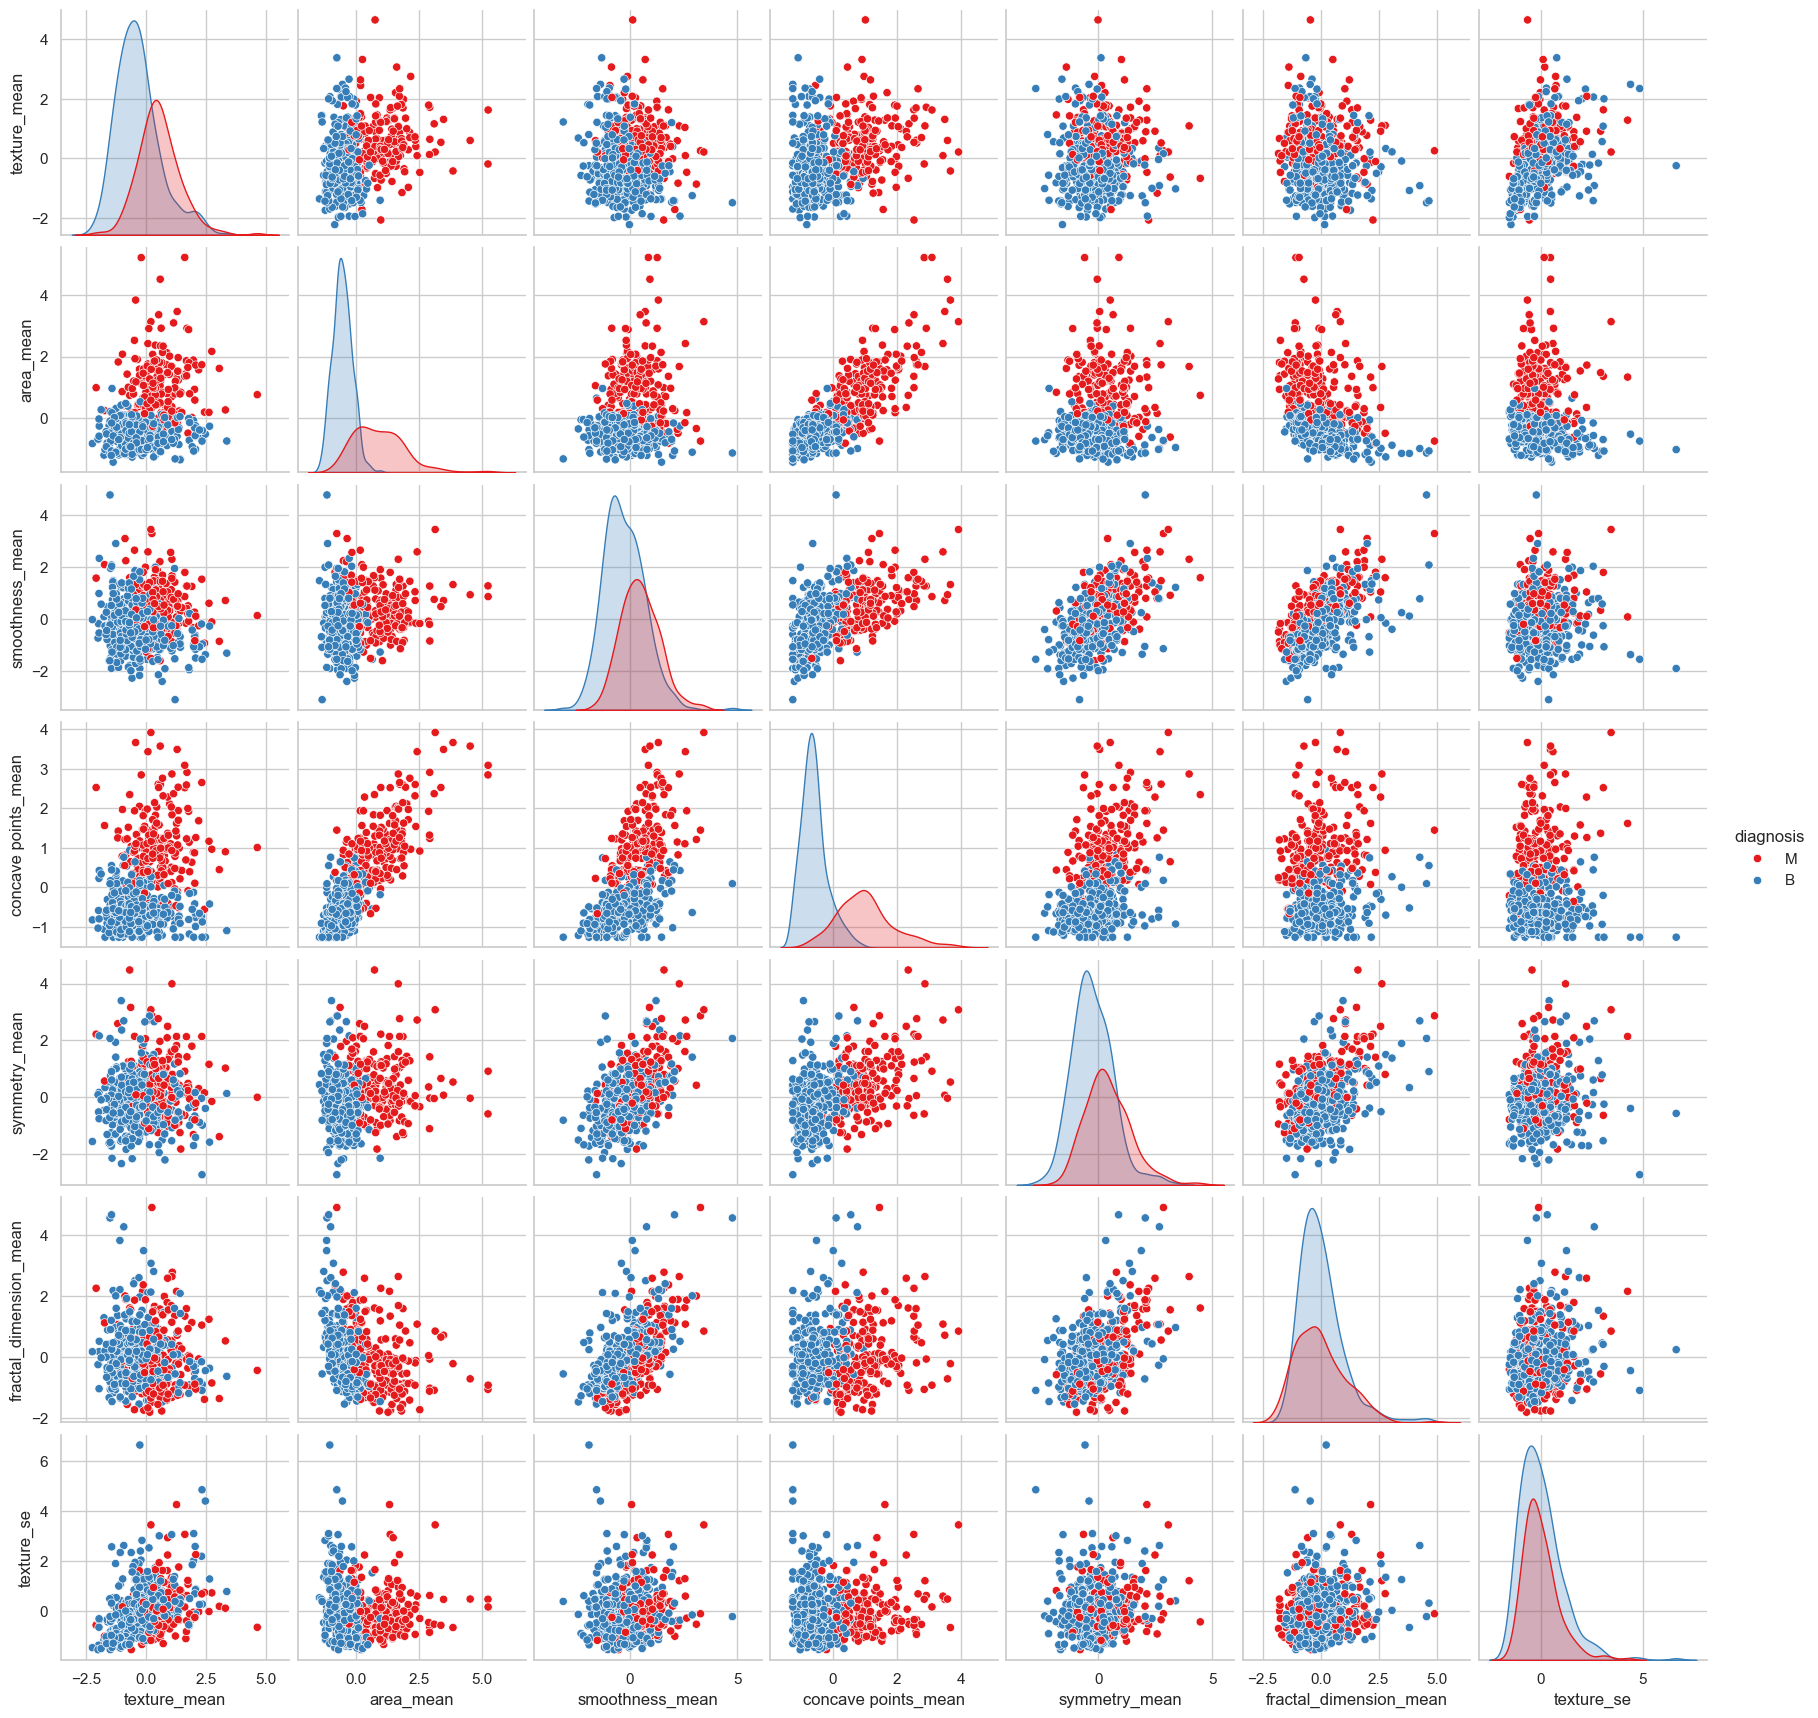

In [187]:
X_norm = (X_filtered - X_filtered.mean()) / X_filtered.std()

data_1 = pd.concat([y, X_norm.iloc[:,0:7]], axis=1)

plt.figure(figsize=(12, 12))
grid = sns.pairplot(data=data_1, kind="scatter", hue="diagnosis", palette="Set1")
plt.show()

<Figure size 1200x1200 with 0 Axes>

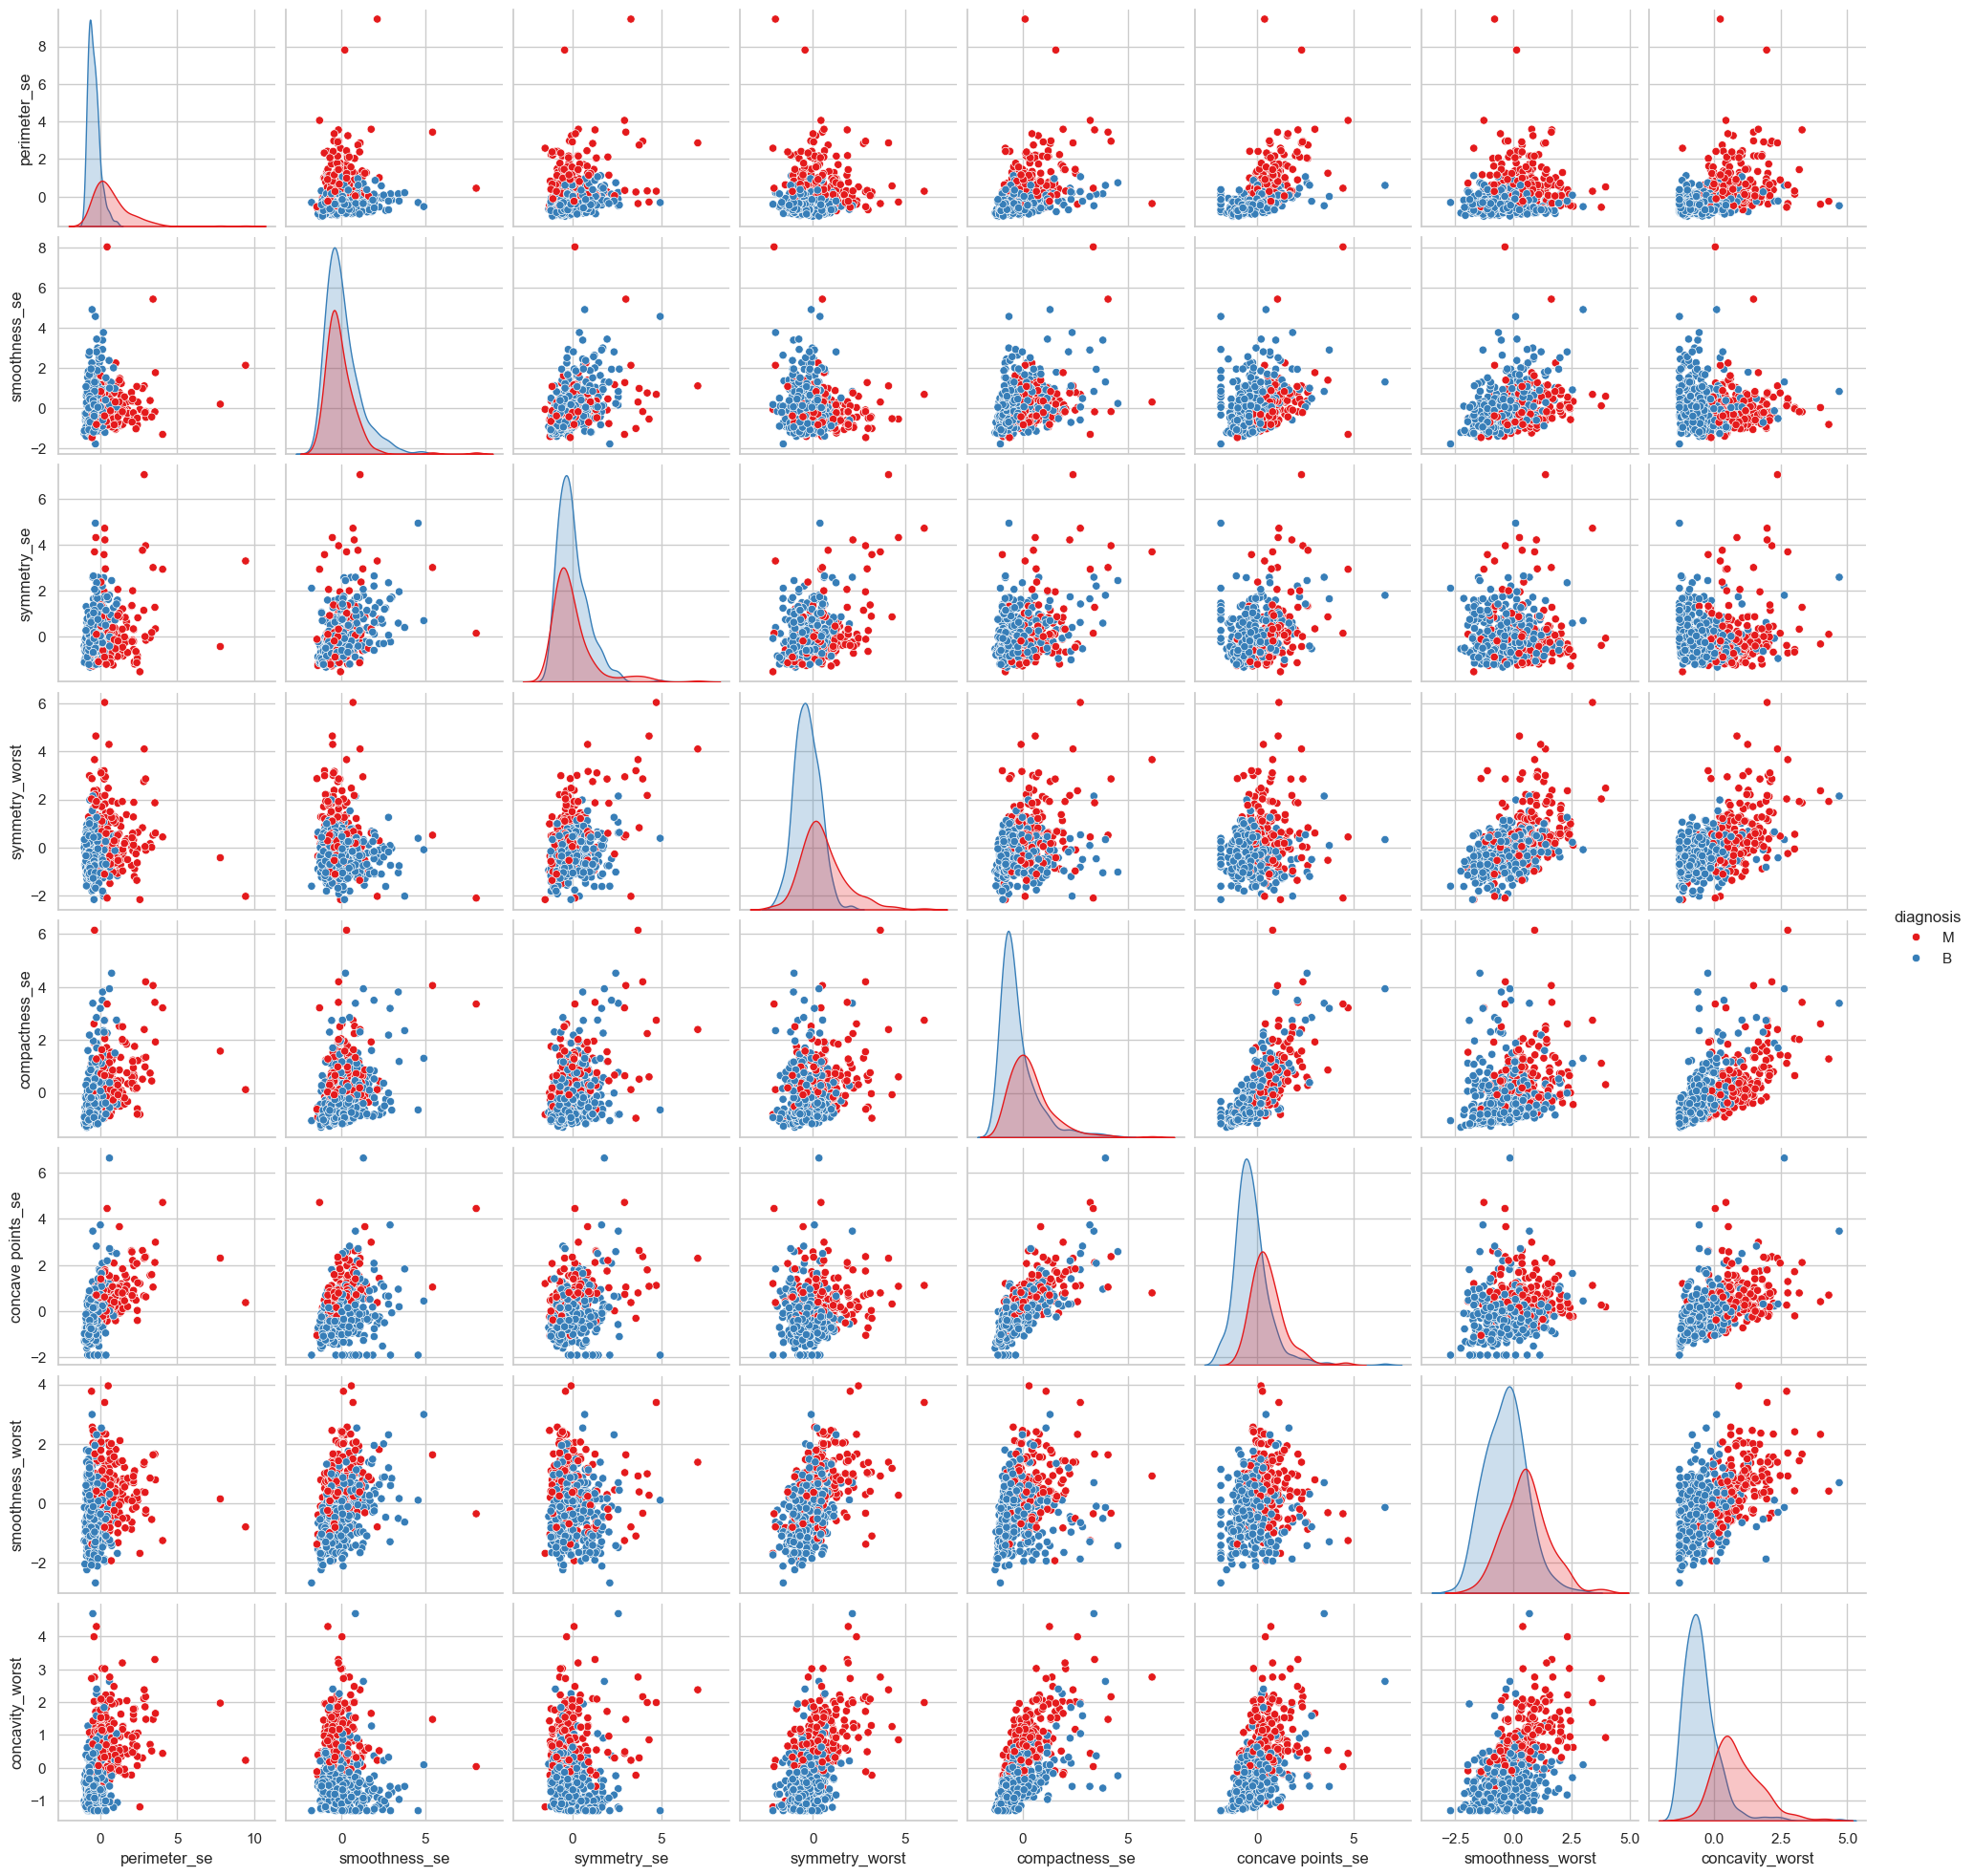

In [189]:
data_2 = pd.concat([y, X_norm.iloc[:,7:]], axis=1)

plt.figure(figsize=(12, 12))
grid = sns.pairplot(data=data_2, kind="scatter", hue="diagnosis", palette="Set1")
plt.show()

Все признаки имеют распределение, отличное от нормального, что подтверждено тестом Шапиро–Уилка, boxplot и гистограммами. На основе тепловой карты корреляций, boxplot с разделением по целевой переменной и роевого графика отобраны признаки с низкой взаимной корреляцией и наилучшим разделением классов. Перед отбором значения были стандартизированы для устранения различий в масштабе признаков.
Отобранные признаки
- texture_mean — отражает особенности текстуры ткани, различия выражены между классами.
- area_mean — показатель среднего размера образования, хорошо разделяет классы.
- smoothness_mean — характеризует однородность контуров.
- concave points_mean — фиксирует вогнутость границ, сильный предиктор.
- symmetry_mean — описывает асимметрию, различия заметны по классам.
- fractal_dimension_mean — отражает сложность границ образования.
- texture_se — показывает вариабельность текстуры, дополняет texture_mean.
- perimeter_se — изменчивость периметра, добавляет информацию о размере и форме.
- smoothness_se — вариабельность гладкости, помогает выявлять нестабильные образования.
- symmetry_se — изменчивость симметрии, усиливает значимость symmetry_mean.
- symmetry_worst — крайние значения асимметрии, хорошо различают классы.
- compactness_se — изменчивость компактности, отражает неоднородность структуры.
- concave points_se — изменчивость вогнутости, усиливает информативность concave points_mean.
- smoothness_worst — экстремальные значения гладкости, усиливают значение smoothness_mean.
- concavity_worst — максимальные проявления вогнутости, критически важны для разделения классов.

Выбранный нормализованный поднабор обладает низкой избыточностью и высокой предсказательной способностью. Наличие признаков как среднего уровня, так и вариабельности и «worst»-значений обеспечивает более устойчивое разделение классов при построении моделей классификации.